In [2]:
import re
import numpy as np
import pandas as pd
import io
import pickle
import torch
from typing import Any, Dict, List, Union, Callable, Optional
from idlfm_sim.harness import _build_observed_arrays, _build_block_test_weights, _test_weight_fn_from_flat
from idlfm_sim import NaiveAbsoluteResidualCP, LocalizedWeightedSplitConformalCP, LocalizedSplitConformalCP, WeightedSplitConformalCP
from idlfm_sim import test_indices_marginal, test_indices_conditional
from matplotlib import pyplot as plt

def parse_printed_pandas_df(text: str) -> pd.DataFrame:
    """
    Reconstruct a DataFrame from a pasted pandas console printout like:

           0      1      2 ...
    0   0.279 -0.636  0.632 ...
    1     NaN    NaN    NaN ...
    ...
          10     11     12 ...
    0  -0.402    NaN    NaN ...
    1   0.077  1.517  0.201 ...
    ...

    Assumptions for this parser:
    - row index is printed at the far left
    - column labels are integers
    - values are numeric or NaN
    - the printout is COMPLETE (not truncated with ...)

    Returns
    -------
    pd.DataFrame
    """
    rows = {}
    current_cols = None

    for raw_line in text.splitlines():
        if not raw_line.strip():
            continue

        # Remove the trailing "\" that pandas prints on wrapped header lines
        line = re.sub(r"\s*\\\s*$", "", raw_line.rstrip())
        tokens = line.split()

        if not tokens:
            continue

        # Header block line: indented and all tokens are integer column labels
        if raw_line[:1].isspace() and all(tok.isdigit() for tok in tokens):
            current_cols = [int(tok) for tok in tokens]
            continue

        # Data row line
        if current_cols is not None and tokens[0].isdigit():
            row_idx = int(tokens[0])
            values = tokens[1:]

            if len(values) != len(current_cols):
                raise ValueError(
                    f"Row {row_idx}: expected {len(current_cols)} values, got {len(values)}"
                )

            row = rows.setdefault(row_idx, {})
            for col, tok in zip(current_cols, values):
                row[col] = np.nan if tok == "NaN" else float(tok)

    if not rows:
        raise ValueError("No data parsed. Make sure you pasted the full printed DataFrame.")

    df = pd.DataFrame.from_dict(rows, orient="index").sort_index()
    df = df.reindex(sorted(df.columns), axis=1)

    df.index.name = None
    df.columns.name = None
    return df

In [3]:
# np.save('residual_IJT.npy', residual_IJT)
residual_IJT = np.load('residual_IJT_psleep.npy')
# residual_IJT = np.load('residual_IJT.npy')
obs_IJT = ~np.isnan(residual_IJT)
I,J,T=residual_IJT.shape
n_var = J-1
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Training rows: observed entries only
ij, jj, tt = np.where(obs_IJT)
y_target = residual_IJT[ij, jj, tt]

train_df = pd.DataFrame({
    "I": ij,
    "J": jj,
    "T": tt.astype(float),
})

# Full grid for prediction, built vectorized
i_full, j_full, t_full = np.indices((I, J, T))
full_df = pd.DataFrame({
    "I": i_full.ravel(),
    "J": j_full.ravel(),
    "T": t_full.ravel().astype(float),
})

pre = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["I", "J"]),
        ("num", "passthrough", ["T"]),
    ]
)

model = Pipeline([
    ("pre", pre),
    ("reg", LinearRegression()),
])

model.fit(train_df, y_target)
Y_pred_flat = model.predict(full_df)
residual_IJT_fit = Y_pred_flat.reshape(I, J, T)


In [14]:
channels = ['activity_calories','fairly_active_minutes','elevation','steps','minute_deep','minute_wake']

In [15]:
pre.fit_transform(train_df)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2692280 stored elements and shape (898162, 657)>

In [4]:
def kernel_regress_time_matrix(Y, mask=None, loo = False,bandwidth=5.0):
    """
    Exact Gaussian kernel regression along time for each (i,j) row.

    Parameters
    ----------
    Y : array, shape (I, J, T)
    mask : bool array, same shape as Y, optional
        True where observed. If None, uses ~np.isnan(Y).
    bandwidth : float
        Gaussian bandwidth in time units.

    Returns
    -------
    Y_hat : array, shape (I, J, T)
    """
    Y = np.asarray(Y, dtype=float)
    I, J, T = Y.shape

    if mask is None:
        mask = ~np.isnan(Y)
    mask = np.asarray(mask, dtype=bool)

    # Flatten rows: each row is one (i,j) time series
    R = I * J
    Y2 = Y.reshape(R, T)
    M2 = mask.reshape(R, T).astype(float)

    # Fill missing with 0 in numerator; denominator handles normalization
    Y_obs = np.where(M2 > 0, Y2, 0.0)

    # Precompute kernel matrix K[target_t, source_s]
    t = np.arange(T, dtype=float)
    d = t[:, None] - t[None, :]
    K = np.exp(-0.5 * (d / bandwidth) ** 2)
    if loo:
        np.fill_diagonal(K, 0.0)
    # Vectorized numerator/denominator
    num = Y_obs @ K.T          # (R, T)
    den = M2 @ K.T             # (R, T)

    Y_hat2 = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)
    return Y_hat2.reshape(I, J, T)

In [5]:
Y_hat = kernel_regress_time_matrix(
    residual_IJT,
    mask=obs_IJT,
    loo = True,
    bandwidth=5.0,
)
residual2_IJT = residual_IJT - Y_hat

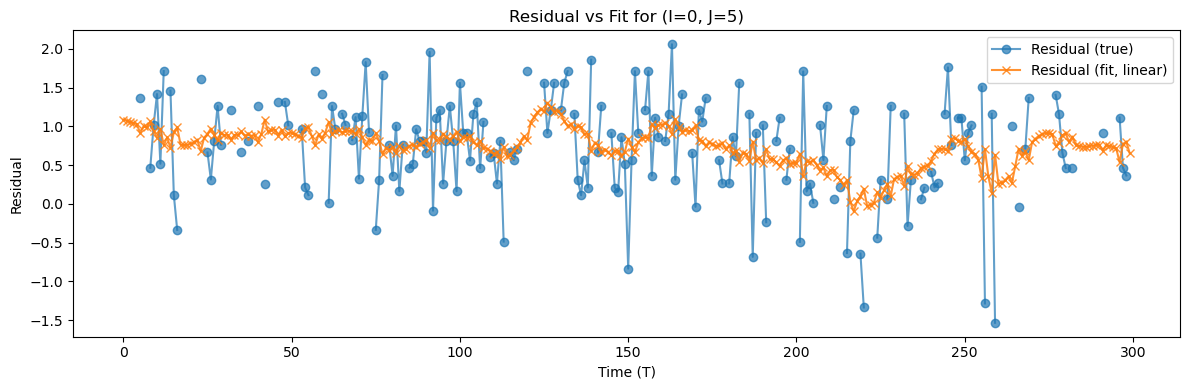

In [18]:
# Choose a subject (i), and variable/stream (j) to plot
i_plot = 0         # Change as needed to plot another subject
j_plot = 5         # Change as needed to plot another stream/variable

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.arange(T), residual_IJT[i_plot, j_plot], label="Residual (true)", marker='o', alpha=0.7)
ax.plot(np.arange(T), Y_hat[i_plot, j_plot], label="Residual (fit, linear)", marker='x', alpha=0.85)
ax.set_xlabel("Time (T)")
ax.set_ylabel("Residual")
ax.set_title(f"Residual vs Fit for (I={i_plot}, J={j_plot})")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
import ruptures as rpt


# ----------------------------
# NaN handling: linear interpolation + edge fill
# ----------------------------
def _interp_1d(y: np.ndarray) -> np.ndarray:
    """Return y with NaNs filled by linear interpolation (then edge-filled)."""
    y = np.asarray(y, dtype=float)
    n = y.size
    if n == 0:
        return y
    x = np.arange(n)
    ok = np.isfinite(y)
    if not np.any(ok):
        # all missing -> return zeros (or raise if you prefer)
        return np.zeros_like(y, dtype=float)
    # linear interpolation over finite points
    y_filled = np.interp(x, x[ok], y[ok])
    return y_filled


def _interp_2d(Y: np.ndarray) -> np.ndarray:
    """Column-wise interpolate NaNs in a (T, J) signal."""
    Y = np.asarray(Y, dtype=float)
    T, J = Y.shape
    out = np.empty_like(Y, dtype=float)
    for j in range(J):
        out[:, j] = _interp_1d(Y[:, j])
    return out


# ----------------------------
# Build a ruptures detector
# ----------------------------
def _make_algo(
    algo: str,
    model: str = "l2",
    min_size: int = 5,
    jump: int = 1,
):
    """
    algo:
      - "pelt": penalized segmentation, use predict(pen=...)
      - "binseg": binary segmentation, use predict(n_bkps=...)
      - "window": window-based, use predict(n_bkps=...) or pen (depends on version)
    """
    algo = algo.lower()
    if algo == "pelt":
        return rpt.Pelt(model=model, min_size=min_size, jump=jump)  # fit -> predict(pen) :contentReference[oaicite:2]{index=2}
    if algo == "binseg":
        return rpt.Binseg(model=model, min_size=min_size, jump=jump)  # :contentReference[oaicite:3]{index=3}
    if algo == "window":
        return rpt.Window(model=model, min_size=min_size, jump=jump)
    raise ValueError(f"Unknown algo={algo!r}")


# ----------------------------
# Core: detect change points
# ----------------------------
def detect_changepoints_residual_IJT(
    residual_IJT: np.ndarray,
    *,
    mode: str = "per_ij",         # "per_ij" or "per_i"
    algo: str = "pelt",           # "pelt" | "binseg" | "window"
    model: str = "l2",            # common: "l2", "l1", "rbf", etc.
    pen: float = 10.0,            # used by pelt
    n_bkps: int = 5,              # used by binseg/window
    min_size: int = 5,
    jump: int = 1,
    preprocess: str = "interp",   # "interp" or "none"
) -> dict:
    """
    residual_IJT: array (I, J, T) with possible NaNs.

    Returns:
      if mode="per_ij":
        dict[(i, j)] -> list of breakpoints bkps (includes T at the end)
      if mode="per_i":
        dict[i] -> list of breakpoints bkps (includes T at the end)

    Notes:
      - ruptures returns a sorted list of segment end indices, typically including T as the last breakpoint.
        The actual change points are bkps[:-1]. :contentReference[oaicite:4]{index=4}
    """
    r = np.asarray(residual_IJT)
    if r.ndim != 3:
        raise ValueError(f"residual_IJT must be 3D (I,J,T), got shape {r.shape}")
    I, J, T = r.shape

    mode = mode.lower()
    preprocess = preprocess.lower()

    out = {}

    if mode == "per_ij":
        for i in range(I):
            for j in range(J):
                y = r[i, j, :]
                if preprocess == "interp":
                    y_use = _interp_1d(y)
                elif preprocess == "none":
                    # WARNING: NaNs can cause unexpected results in ruptures
                    y_use = np.asarray(y, dtype=float)
                else:
                    raise ValueError(f"Unknown preprocess={preprocess!r}")

                # ruptures accepts (n_samples,) or (n_samples, n_features) :contentReference[oaicite:5]{index=5}
                algo_obj = _make_algo(algo=algo, model=model, min_size=min_size, jump=jump)
                algo_obj.fit(y_use)

                if algo.lower() == "pelt":
                    bkps = algo_obj.predict(pen=pen)  # :contentReference[oaicite:6]{index=6}
                else:
                    bkps = algo_obj.predict(n_bkps=n_bkps)

                out[(i, j)] = bkps

        return out

    if mode == "per_i":
        for i in range(I):
            Y = r[i, :, :].T  # (T, J)
            if preprocess == "interp":
                Y_use = _interp_2d(Y)
            elif preprocess == "none":
                Y_use = np.asarray(Y, dtype=float)
            else:
                raise ValueError(f"Unknown preprocess={preprocess!r}")

            algo_obj = _make_algo(algo=algo, model=model, min_size=min_size, jump=jump)
            algo_obj.fit(Y_use)

            if algo.lower() == "pelt":
                bkps = algo_obj.predict(pen=pen)
            else:
                bkps = algo_obj.predict(n_bkps=n_bkps)

            out[i] = bkps

        return out

    raise ValueError(f"Unknown mode={mode!r}. Use 'per_ij' or 'per_i'.")


def bkps_to_changepoints(bkps: list[int]) -> np.ndarray:
    """Convert ruptures bkps list to change-point indices (exclude last endpoint)."""
    if bkps is None:
        return np.array([], dtype=int)
    bkps = np.asarray(bkps, dtype=int)
    if bkps.size == 0:
        return bkps
    return bkps[:-1]


In [ ]:
eps = 1e-6
bkps_ij = detect_changepoints_residual_IJT(
    np.log(residual2_IJT**2+eps),
    mode="per_ij",
    algo="pelt",
    model="l2",
    pen=20.0,
    min_size=20,
    preprocess="interp",
)

In [ ]:
bkps_ij

{(0, 0): [109, 130, 247, 300],
 (0, 1): [23, 47, 68, 91, 116, 150, 170, 190, 219, 239, 259, 280, 300],
 (0, 2): [128, 259, 280, 300],
 (0, 3): [41, 94, 114, 149, 194, 234, 254, 300],
 (0, 4): [24, 66, 93, 113, 189, 280, 300],
 (0, 5): [25, 63, 120, 183, 234, 254, 278, 300],
 (1, 0): [130, 154, 300],
 (1, 1): [43, 66, 89, 114, 136, 300],
 (1, 2): [50, 100, 153, 272, 300],
 (1, 3): [37, 153, 248, 300],
 (1, 4): [300],
 (1, 5): [300],
 (2, 0): [170, 190, 215, 300],
 (2, 1): [28, 168, 188, 300],
 (2, 2): [215, 300],
 (2, 3): [241, 300],
 (2, 4): [97, 124, 211, 300],
 (2, 5): [85, 108, 131, 194, 215, 249, 278, 300],
 (3, 0): [20, 46, 81, 107, 280, 300],
 (3, 1): [92, 114, 203, 280, 300],
 (3, 2): [78, 166, 186, 280, 300],
 (3, 3): [81, 107, 167, 190, 260, 280, 300],
 (3, 4): [76, 99, 135, 164, 238, 300],
 (3, 5): [20, 59, 300],
 (4, 0): [53, 101, 184, 300],
 (4, 1): [67, 107, 146, 171, 200, 220, 300],
 (4, 2): [20, 220, 242, 300],
 (4, 3): [59, 101, 225, 300],
 (4, 4): [32, 55, 119, 151, 17

In [ ]:
import pickle

# with open("bkps_ij2.pkl", "wb") as f:
#     pickle.dump(bkps_ij, f)
# with open("bkps_ij.pkl", "rb") as f:
#     bkps_ij = pickle.load(f)

with open("bkps_ij_s.pkl", "wb") as f:
    pickle.dump(bkps_ij, f)

In [7]:
# with open("bkps_ij.pkl", "wb") as f:
#     pickle.dump(bkps_ij, f)
with open("bkps_ij_s.pkl", "rb") as f:
    bkps_ij = pickle.load(f)

In [8]:
def make_piecewise_constant_P_hat(
    bkps_ij,
    shape,                 # (I, J, T)
    *,
    seed=42,
    p_low=0.2,
    p_high=0.8,
    clip_eps=1e-6,
    sampler=None,
    variance_source=None,   # optional array of shape (I, J, T)
    variance_mode="linear", # "linear" or "inverse"
    variance_eps=1e-8,
    ddof=0,
):
    """
    Build P_hat of shape (I, J, T) such that for each (i, j),
    P_hat[i, j, :] is constant within each changepoint window and
    can change across windows.

    If variance_source is provided, then for each fixed (i, j),
    each segment/window gets a probability based on the variance of
    variance_source[i, j, start:end] relative to the other windows
    of the same (i, j).

    Parameters
    ----------
    bkps_ij : dict
        Example:
        {
            (0, 0): [T],
            (0, 1): [T],
            (0, 2): [t1, T],
            (0, 3): [t1, t2, T],
            ...
        }
        The trailing T is ignored.
    shape : tuple
        (I, J, T)
    seed : int
        RNG seed.
    p_low, p_high : float
        Range for segment-wise probabilities.
    clip_eps : float
        Final probabilities are clipped to [clip_eps, 1 - clip_eps].
    sampler : callable or None
        Optional custom sampler with signature:
            sampler(rng, n_segments, i, j) -> array of shape (n_segments,)
        Used only if variance_source is None.
    variance_source : np.ndarray or None
        Optional array of shape (I, J, T). If provided, use within-window
        variance to assign probabilities.
    variance_mode : str
        "linear"  -> higher variance => higher p_hat
        "inverse" -> higher variance => lower p_hat
    variance_eps : float
        Small constant to avoid divide-by-zero if all window variances match.
    ddof : int
        Degrees of freedom for np.nanvar.
    """
    I, J, T = shape
    rng = np.random.default_rng(seed)
    P_hat = np.empty((I, J, T), dtype=float)

    if sampler is None:
        def sampler(rng, n_segments, i, j):
            return rng.uniform(p_low, p_high, size=n_segments)

    if variance_source is not None:
        variance_source = np.asarray(variance_source, dtype=float)
        if variance_source.shape != (I, J, T):
            raise ValueError(
                f"variance_source must have shape {(I, J, T)}, got {variance_source.shape}"
            )

    for i in range(I):
        for j in range(J):
            bkps = bkps_ij.get((i, j), [T])

            # Keep only actual changepoints in (0, T); omit trailing T
            cps = sorted({int(b) for b in bkps if 0 < int(b) < T})

            # Segment boundaries: [0, cp1), [cp1, cp2), ..., [last_cp, T)
            edges = [0] + cps + [T]
            n_segments = len(edges) - 1

            if variance_source is not None:
                seg_var = np.empty(n_segments, dtype=float)

                for k, (start, end) in enumerate(zip(edges[:-1], edges[1:])):
                    x = variance_source[i, j, start:end]
                    if x.size <= 1:
                        seg_var[k] = 0.0
                    else:
                        # Use mean squared error (around 0) instead of variance around the segment mean
                        seg_var[k] = float(np.nanmean(x ** 2))

                vmin = float(np.nanmin(seg_var))
                vmax = float(np.nanmax(seg_var))

                if vmax - vmin <= variance_eps:
                    seg_p = np.full(n_segments, 0.5 * (p_low + p_high), dtype=float)
                else:
                    scaled = (seg_var - vmin) / (vmax - vmin)
                    if variance_mode == "linear":
                        seg_p = p_low + scaled * (p_high - p_low)
                    elif variance_mode == "inverse":
                        seg_p = p_high - scaled * (p_high - p_low)
                    else:
                        raise ValueError("variance_mode must be 'linear' or 'inverse'")
            else:
                seg_p = np.asarray(sampler(rng, n_segments, i, j), dtype=float)
                if seg_p.shape != (n_segments,):
                    raise ValueError(
                        f"sampler must return shape ({n_segments},), got {seg_p.shape}"
                    )

            seg_p = np.clip(seg_p, clip_eps, 1.0 - clip_eps)

            for k, (start, end) in enumerate(zip(edges[:-1], edges[1:])):
                P_hat[i, j, start:end] = seg_p[k]

    return P_hat

In [9]:
P_hat = make_piecewise_constant_P_hat(
    bkps_ij,
    shape=residual2_IJT.shape,
    variance_source=residual2_IJT,
    variance_mode="linear",   # higher variance => higher p_hat
    p_low=0.2,
    p_high=0.8,
)

C:\Users\Xiaoke\AppData\Local\Temp\ipykernel_49316\494343523.py:95: RuntimeWarning: Mean of empty slice
  seg_var[k] = float(np.nanmean(x ** 2))
C:\Users\Xiaoke\AppData\Local\Temp\ipykernel_49316\494343523.py:97: RuntimeWarning: All-NaN slice encountered
  vmin = float(np.nanmin(seg_var))
C:\Users\Xiaoke\AppData\Local\Temp\ipykernel_49316\494343523.py:98: RuntimeWarning: All-NaN slice encountered
  vmax = float(np.nanmax(seg_var))


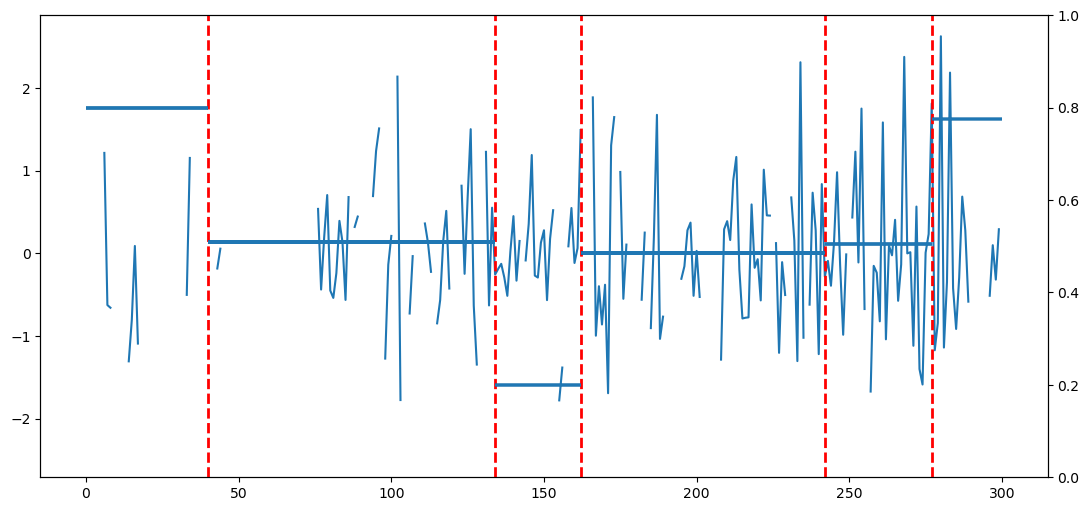

In [ ]:

i=8
j=5
cps=np.array(bkps_ij[(i,j)])
fig, ax1 = plt.subplots(figsize=(13, 6))
ax1.plot(residual2_IJT[i,j,:300])
ax2 = ax1.twinx() 
ax2.set_ylim(0,1)
cps_sub=cps[cps<300]
for enu, cp in enumerate(cps_sub):
    ax2.axvline(x=cp, color='r', linestyle='--', linewidth=2)
    if enu==0:
        ax2.hlines(y=P_hat[i,j,:cp],xmin=0,xmax=cp)
        continue
    ax2.hlines(y=P_hat[i,j,(cps[enu-1]):cp],xmin=cps[enu-1],xmax=cp)
    if enu==(len(cps_sub)-1):
        ax2.hlines(y=P_hat[i,j,cp:300],xmin=cp,xmax=300)

y:[0.20003135 0.20003135 0.20003135 0.20003135 0.20003135 0.20003135
 0.20003135 0.20003135 0.20003135 0.20003135 0.20003135 0.20003135
 0.20003135 0.20003135 0.20003135 0.20003135 0.20003135 0.20003135
 0.20003135 0.20003135 0.20003135 0.20003135 0.20003135 0.20003135], x:23-47, xmax:47
y:[0.20391935 0.20391935 0.20391935 0.20391935 0.20391935 0.20391935
 0.20391935 0.20391935 0.20391935 0.20391935 0.20391935 0.20391935
 0.20391935 0.20391935 0.20391935 0.20391935 0.20391935 0.20391935
 0.20391935 0.20391935 0.20391935], x:47-68, xmax:68
y:[0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2
 0.2 0.2 0.2 0.2 0.2], x:68-91, xmax:91
y:[0.30233354 0.30233354 0.30233354 0.30233354 0.30233354 0.30233354
 0.30233354 0.30233354 0.30233354 0.30233354 0.30233354 0.30233354
 0.30233354 0.30233354 0.30233354 0.30233354 0.30233354 0.30233354
 0.30233354 0.30233354 0.30233354 0.30233354 0.30233354 0.30233354
 0.30233354], x:91-116, xmax:116
y:[0.20234285 0.20234285 0.20234285 0

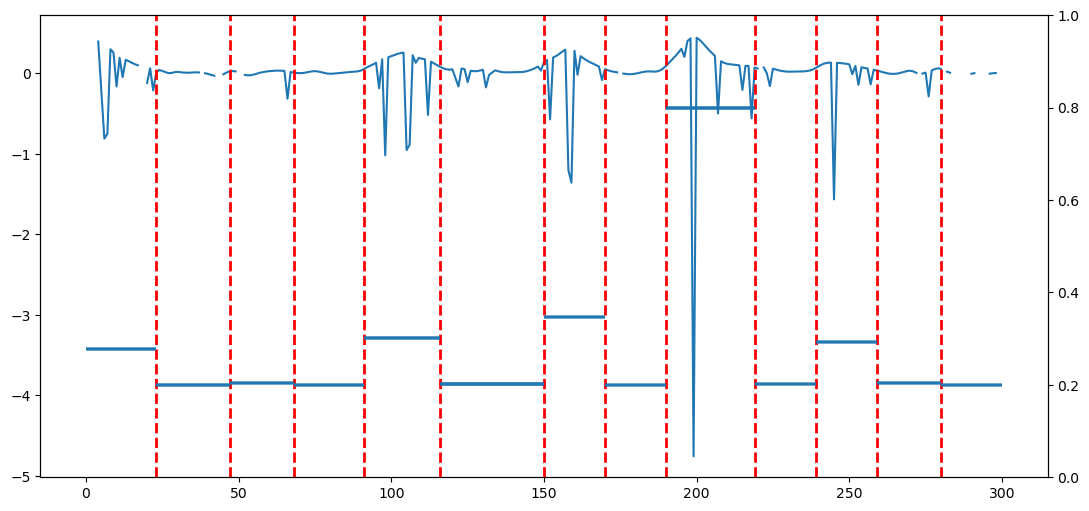

In [ ]:

i=0
j=1
cps=np.array(bkps_ij[(i,j)])
fig, ax1 = plt.subplots(figsize=(13, 6))
ax1.plot(residual2_IJT[i,j,:300])
ax2 = ax1.twinx() 
ax2.set_ylim(0,1)
cps_sub=cps[cps<300]
for enu, cp in enumerate(cps_sub):
    ax2.axvline(x=cp, color='r', linestyle='--', linewidth=2)
    if enu==0:
        ax2.hlines(y=P_hat[i,j,:cp],xmin=0,xmax=cp)
        continue
    ax2.hlines(y=P_hat[i,j,(cps[enu-1]):cp],xmin=cps[enu-1],xmax=cp)
    print(f'y:{P_hat[i,j,(cps[enu-1]):cp]}, x:{cps[enu-1]}-{cp}, xmax:{cp}')
    if enu==(len(cps_sub)-1):
        ax2.hlines(y=P_hat[i,j,cp:300],xmin=cp,xmax=300)

In [10]:
I_sub = 50
T_sub = 100
alpha=0.1
seed_miss = 42
seed = 1
rng = np.random.default_rng(seed=seed_miss)
U = rng.random(P_hat.shape)
A_hat = U > P_hat
idx_sub = np.sort(rng.choice(I, size=min(I_sub, I), replace=False))
# residual_sub_IJT = residual_IJT[idx_sub, :, :T_sub]
residual_sub_IJT = residual2_IJT[idx_sub, :, :T_sub]
obs_sub_IJT = obs_IJT[idx_sub, :, :T_sub]
M_hat  = A_hat & obs_IJT
P_eval = P_hat[idx_sub, :, :T_sub]
M_eval = M_hat[idx_sub, :, :T_sub]   # shape (I_sub, J, T_sub)

train_mask = np.zeros((I_sub, J, T_sub), dtype=bool)
test_mask  = np.zeros((I_sub, J, T_sub), dtype=bool)
cal_mask   = np.zeros((I_sub, J, T_sub), dtype=bool)

# --- 1) TRAIN: uniform 50% of ALL observed per i ---
obs_idx = np.argwhere(obs_sub_IJT)  # (N,3): [i,j,t]

for i in range(I_sub):
    rows = np.flatnonzero(obs_idx[:, 0] == i)
    n = rows.size
    if n == 0:
        continue

    rng.shuffle(rows)               # shuffle indices for this i
    n_train = n // 2                # 50% per i (floor if odd; see note below)

    train_rows = obs_idx[rows[:n_train]]
    train_mask[train_rows[:, 0], train_rows[:, 1], train_rows[:, 2]] = True

# --- 2) From the REST of observed, carve TEST then CAL ---
rest_obs = obs_sub_IJT & (~train_mask)

test_mask = obs_sub_IJT & (~M_eval)    # test = ~M_eval among remaining observed
cal_mask  = obs_sub_IJT & ( M_eval)    # cal = the rest

In [11]:
def flat_idx(mask_IJT: np.ndarray) -> np.ndarray:
    return np.flatnonzero(mask_IJT.ravel()).astype(np.int64)
def decode_flat_idx(idx: np.ndarray, J: int, T: int):
        """Return (i, j, t) arrays from flat indices for an (I, J, T) C-order ravel."""
        idx = np.asarray(idx, dtype=np.int64)
        i = idx // (J * T)
        rem = idx % (J * T)
        j = rem // T
        t = rem % T
        return i, j, t

X_cal_idx = flat_idx(cal_mask)
Y_cal_true = residual_sub_IJT.ravel()[X_cal_idx]
Y_cal_fit = np.zeros_like(Y_cal_true)

X_test_idx = flat_idx(test_mask)

# Build probability lookup callable for CP methods that support weighting (missingness odds)
p_flat = 1-P_eval.ravel()
p_fn = (lambda flat_idx, arr=p_flat: arr[np.asarray(flat_idx, dtype=int)])

In [ ]:
from torch._C import device
from twfv import run_em_like
degree: int = 3
max_outer: int = 50
grad_steps: int = 5
lr: float = 0.1
M_ctrl: int = 20
r_fit: int = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def idx_to_mask_torch(idx, I, J, T, device=None):
    """
    Convert a 1D idx array and dimensions (I, J, T) to a boolean torch mask of shape (I, T, J).
    """
    flat_mask = np.zeros(I * J * T, dtype=bool)
    flat_mask[idx] = True
    # Reshape to (I, J, T) to match flatten convention, then transpose to (I, T, J)
    mask = flat_mask.reshape(I, J, T).transpose(0, 2, 1)
    return torch.as_tensor(mask, dtype=torch.bool, device=device)
residual_sub_torch = torch.as_tensor(np.swapaxes(residual_sub_IJT,1,2), dtype=torch.float32, device=device)
M_train_torch = torch.as_tensor(np.swapaxes(train_mask,1,2), dtype=torch.bool, device=device)
save_name = f"em_result_real_{seed_miss}_r{r_fit}.pkl"
if not os.path.exists(save_name):
    em_result = run_em_like(
            Y=residual_sub_torch,
            M_mask=M_train_torch,
            r=r_fit,
            M_ctrl=int(M_ctrl),
            degree=degree,
            max_outer=max_outer,
            grad_steps=grad_steps,
            lr=lr,
            device=device,
            warp_eta=0.2,
            freeze_warp=True,
            use_woodbury=True,
            collect_diagnostics=True,
            diagnostics_t_head=10,
            lambda_C=0.01,
        )
    with open(save_name, "wb") as f:
        pickle.dump(em_result, f)
else:
    with open(save_name, "rb") as f:
        em_result = pickle.load(f)

In [14]:
from twfv import run_factor_channel_conformal
L, a2, psi, s, kappa, C, u_tilde, F_tilde, history = em_result
M_cal_torch = torch.as_tensor(cal_mask, dtype=torch.bool, device=device)
out_new = run_factor_channel_conformal(
    residual_sub_torch, M_cal_torch, L, psi, s, a2,
    alpha=0.1,
    factor_mode="leave_target_out",
    score_kind="pit",
)
lower_decomp, upper_decomp, center_decomp,cov_decomp = out_new["intervals"].values()
coverage_decomp  = (lower_decomp[~M_cal_torch]<residual_sub_torch[~M_cal_torch]) & (residual_sub_torch[~M_cal_torch]<upper_decomp[~M_cal_torch])
coverage_decomp.float().mean()

RuntimeError: cusolver error: CUSOLVER_STATUS_INTERNAL_ERROR, when calling `cusolverDnXpotrf( handle, params, uplo, n, dataTypeA, A, lda, computeType, bufferOnDevice, workspaceInBytesOnDevice, bufferOnHost, workspaceInBytesOnHost, info )`. If you keep seeing this error, you may use `torch.backends.cuda.preferred_linalg_library()` to try linear algebra operators with other supported backends. See https://pytorch.org/docs/stable/backends.html#torch.backends.cuda.preferred_linalg_library

In [ ]:
from idlfm_sim.harness import _localizer_features_from_flat_idx
learned_repr_fn = None
use_learned_localizer=True
learned_localizer_frac: float = 0.5
learned_localizer_model: str = "rf"
X_loc = _localizer_features_from_flat_idx(
        X_cal_idx,
        I=I_sub,
        J=J,
        T=T_sub,
        mean_pred_flat=None,
    )
try:
    if learned_localizer_model in {"rf", "random_forest", "randomforest"}:
        from sklearn.ensemble import RandomForestRegressor  # type: ignore

        model = RandomForestRegressor(
            n_estimators=200,
            min_samples_leaf=5,
            random_state=seed,
            n_jobs=-1,
        )
    else:
        from sklearn.linear_model import LinearRegression  # type: ignore

        model = LinearRegression()
    model.fit(X_loc, np.abs(Y_cal_true-Y_cal_fit))
except Exception:
    pass



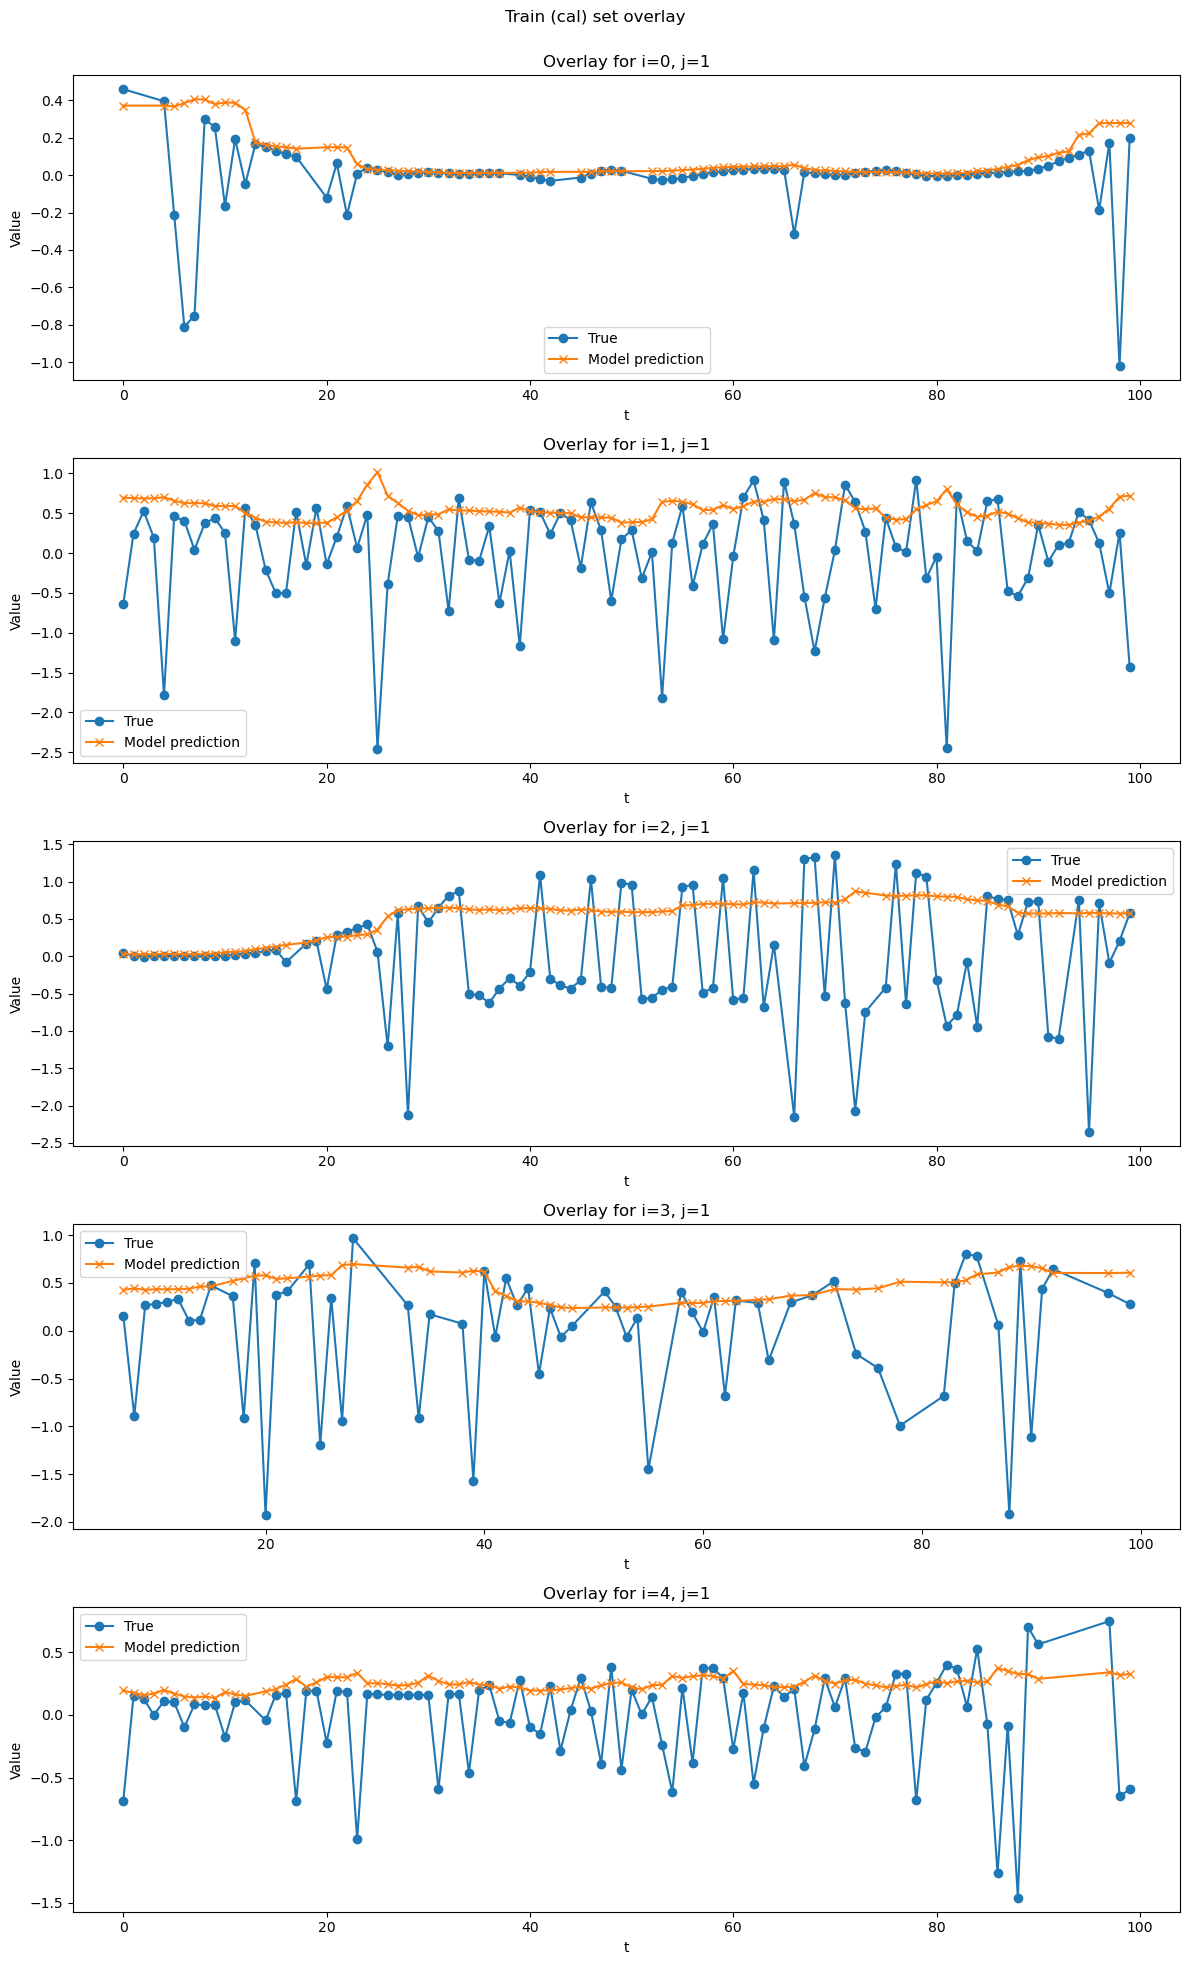

In [ ]:
def plot_overlayed_predictions(i_range, j, model, Y, shape, title=None):
    """
    Plots Y_true and model prediction for all t in T, for a given j and a range of i.

    Parameters:
        i_range (iterable): Indices for i to plot over (len plots).
        j (int): The fixed second index.
        model: Trained model with .predict(X).
        Y: Full (I, J, T) array of true Y values.
        shape: Tuple (I, J, T) used for flat index mapping.
        title: Optional figure title.
    """
    I, J, T = shape
    fig, axes = plt.subplots(len(i_range), 1, figsize=(12, 4*len(i_range)), squeeze=False)
    axes = axes.flatten()  # shape (nplots,)
    for idx, i in enumerate(i_range):
        # Get observed time indices for (i, j)
        t_idx = np.where(~np.isnan(Y[i, j, :]))[0]
        if len(t_idx) == 0:
            axes[idx].set_title(f"(i={i}, j={j}) - No observed data")
            axes[idx].axis('off')
            continue
        # Flat indices for these
        flat_indices = [i * J * T + j * T + t for t in t_idx]
        # Features for prediction (same as for fitting)
        Xq = _localizer_features_from_flat_idx(flat_indices, I=I, J=J, T=T, mean_pred_flat=None)
        # Model prediction
        y_pred = model.predict(Xq)
        # True values
        y_true = Y[i, j, t_idx]
        axes[idx].plot(t_idx, y_true, label="True", marker='o', color='C0')
        axes[idx].plot(t_idx, y_pred, label="Model prediction", marker='x', color='C1')
        axes[idx].set_title(f"Overlay for i={i}, j={j}")
        axes[idx].set_xlabel("t")
        axes[idx].set_ylabel("Value")
        axes[idx].legend()
    if title is not None:
        fig.suptitle(title)
    plt.tight_layout(rect=[0,0,1,0.98] if title else None)
    plt.show()


# Example usage for calibration set (Y_cal_true) and model:
# The data you have in variables is: 
# - Y_cal_true is flat, but true Y is residual_sub_IJT (I_sub, J, T_sub)
plot_overlayed_predictions(range(5),1, model, residual_sub_IJT, (I_sub, J, T_sub), title="Train (cal) set overlay")

# For test set, you would need similar true and model prediction arrays.

In [ ]:
Y_cal_true-Y_cal_fit

array([ 0.32452637, -0.75854157,  0.72224773, ..., -0.40144884,
       -0.60194416, -0.9336356 ])

In [ ]:
model.score(X_loc, np.abs(Y_cal_true-Y_cal_fit))

0.4665864475809113

In [ ]:
def _repr_fn(idx_query: np.ndarray, *, _model=model, _mean_flat=None) -> np.ndarray:
    idx_query = np.asarray(idx_query, dtype=np.int64).ravel()
    Xq = _localizer_features_from_flat_idx(
        idx_query,
        I=I_sub,
        J=J,
        T=T_sub,
        mean_pred_flat=None,
    )
    z = np.asarray(_model.predict(Xq), dtype=float).reshape(-1, 1)
    return z
learned_repr_fn = _repr_fn

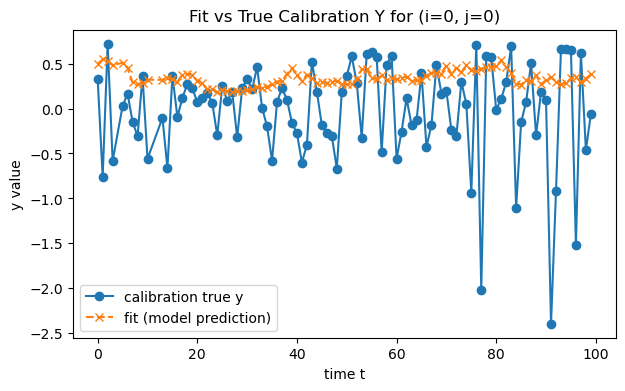

In [ ]:
# Choose a specific (i, j) pair to examine
i, j = 0, 0  # You can change these indices as desired

# Find all time indices for which we have observed data for (i, j)
observed_times = np.where(~np.isnan(residual_sub_IJT[i, j, :]))[0]

# For those times, get X indices in the flat representation (if you have a function, e.g. _flat_idx function)
def _flat_idx(i, j, t, shape):
    # Convert (i, j, t) to flat index for X_loc and Y_cal_true
    I, J, T = shape
    return i * (J * T) + j * T + t

if 'I_sub' in locals():
    I = I_sub
else:
    I = residual_sub_IJT.shape[0]
J = residual_sub_IJT.shape[1]
T = residual_sub_IJT.shape[2]

flat_indices = [_flat_idx(i, j, t, (I, J, T)) for t in observed_times]

# Predict and get the true values
y_pred = _repr_fn(flat_indices).flatten()    # predicted fit using learned_repr_fn / _repr_fn
y_true = [Y_cal_true[idx] for idx in flat_indices]  # true cal y

plt.figure(figsize=(7,4))
plt.plot(observed_times, y_true, 'o-', label='calibration true y')
plt.plot(observed_times, y_pred, 'x--', label='fit (model prediction)')
plt.xlabel("time t")
plt.ylabel("y value")
plt.title(f"Fit vs True Calibration Y for (i={i}, j={j})")
plt.legend()
plt.show()

In [ ]:
bandwidth = 40
use_test_sampling_weight = True
apply_test_weight_to_localized = False
# Optional: build per-block test-sampling weights p^{test} (up to a constant)
test_w_by_block: Optional[Dict[str, np.ndarray]] = None
if use_test_sampling_weight:
    test_w_by_block = _build_block_test_weights(
        res = residual_sub_IJT,
        p = P_eval,
        mix_prob_A2=0.7,
    )

def _instantiate_method(method_key: str, maker: Any,p_fn,bandwidth=40, block_name: Optional[str] = None):
    # If the method name suggests localization, attempt to pass bandwidth
    mk = str(method_key).lower()
    try:
        obj = maker(residual_sub_IJT.shape, alpha,bandwidth)
    except Exception:
        print(str(maker))
        obj = maker(residual_sub_IJT.shape, alpha)
    # Inject missingness probability function (for weighted methods)
    try:
        obj._p_fn = p_fn
    except Exception:
        pass
    
    if learned_repr_fn is not None and ("localized" in mk):
        try:
            obj._repr_fn = learned_repr_fn
        except Exception:
            pass
    # Inject test sampling weights if requested
    if use_test_sampling_weight and test_w_by_block is not None and block_name is not None:
        should_apply = ("weighted" in mk) or (apply_test_weight_to_localized and ("localized" in mk))
        if should_apply:
            try:
                obj._test_w_fn = _test_weight_fn_from_flat(test_w_by_block[block_name])
            except Exception:
                pass
    return obj

# Calibrate each method and evaluate blocks
cp_results: Dict[str, Dict[str, Dict[str, float]]] = {}
is_y1 = np.zeros_like(residual_sub_IJT,dtype=bool)
is_y1[:,:,:] = True
y1_idx, y1_true = _build_observed_arrays(residual_sub_IJT, is_y1)
cal_y1_idx, cal_y1_true = _build_observed_arrays(residual_sub_IJT, is_y1&cal_mask)
res_sub_true = np.zeros_like(residual_sub_IJT)
cal_y1_fit = res_sub_true.ravel()[cal_y1_idx]

In [ ]:
from idlfm_sim.testsamples import _eligible_indices
A_eval = A_hat[idx_sub, :, :T_sub]
res_sub_fit = np.zeros_like(residual_sub_IJT)
n_test=50000
eligible = obs_sub_IJT & (~A_eval)
idx_marg = _eligible_indices(eligible, n=n_test, seed=seed + 101)
idx_cond_a1 = test_indices_conditional(obs_sub_IJT, A_eval, subset="A1", n=n_test,p=P_eval,seed=seed,base_pool="observed_missing")
idx_cond_a2 = test_indices_conditional(obs_sub_IJT, A_eval, subset="A2", n=n_test,p=P_eval,seed=seed,base_pool="observed_missing")
idx_cond_mix = test_indices_conditional(obs_sub_IJT, A_eval, subset="mixture_A1_A2", n=n_test,p=P_eval,seed=seed,base_pool="observed_missing")

In [ ]:
import importlib
import idlfm_sim
importlib.reload(idlfm_sim.harness)
from idlfm_sim.harness import coverage_and_length, window_local_abs_coverage_gap
def eval_block_for_cp(cp_obj: Any, idx: np.ndarray,res:np.ndarray, res_fit:np.ndarray,K_windows=20):
    if idx.size == 0:
        return float("nan"), float("nan"), float("nan"), float("nan")
    if not hasattr(cp_obj, "predict_interval_from_fit"):
        raise AttributeError("CP method must implement predict_interval_from_fit(X_test_idx, Y_test_fit, alpha).")
    y_fit_test = res_fit.ravel()[idx]
    intervals = cp_obj.predict_interval_from_fit(idx, y_fit_test, alpha=alpha)  # type: ignore[attr-defined]
    nan_rows = np.where(np.isnan(intervals[:,0]) | np.isnan(intervals[:,1]))[0]
    print("Indices with nan in lower or upper bound:", idx[nan_rows])
    y_true = res.ravel()[idx]
    cov, medlen, meanlen = coverage_and_length(intervals, y_true)
    # Window-local metric (defaults to response stream j=J-1 because idx is intersected with y1_idx)
    I,J,T=res.shape
    wgap = window_local_abs_coverage_gap(
        intervals=intervals,
        y_true=y_true,
        idx_flat=idx,
        I=I,
        J=J,
        T=T,
        K=K_windows,
        target=float(1.0 - alpha),
        j_filter=J - 1,
    )
    return cov, medlen, meanlen, wgap

In [ ]:
use_test_sampling_weight=False

In [ ]:
learned_repr_fn = None

In [ ]:
# Build list of CP methods to evaluate
methods_list: List[tuple[str, Any]] = []
shape = residual_sub_IJT.shape  # (I, J, T)
cp_methods = {
    "naive": lambda shape, alpha: NaiveAbsoluteResidualCP(shape=shape, alpha=alpha),
    "weighted": lambda shape, alpha: WeightedSplitConformalCP(shape=shape, alpha=alpha),
    "localized": lambda shape, alpha, bandwidth: LocalizedSplitConformalCP(
        shape=shape, alpha=alpha, bandwidth=bandwidth
    ),
    "weighted_localized": lambda shape, alpha, bandwidth: LocalizedWeightedSplitConformalCP(
        shape=shape,
        alpha=alpha,
        bandwidth=bandwidth,
        lhs_use_test_weight=use_test_sampling_weight,
    ),
}
# Instantiate methods once into methods_list
if cp_methods is not None:
    if isinstance(cp_methods, dict):
        for name, maker in cp_methods.items():
            mk = str(name).lower()
            if "localized" in mk:
                init_obj = maker(shape, alpha, bandwidth)
            else:
                init_obj = maker(shape, alpha)
            try:
                init_obj._p_fn = p_fn
            except Exception:
                pass
            if learned_repr_fn is not None and ("localized" in mk):
                try:
                    init_obj._repr_fn = learned_repr_fn
                except Exception:
                    pass
            methods_list.append((str(name), init_obj))
    else:
        for maker in cp_methods:
            try:
                init_obj = maker(shape, alpha, bandwidth)
            except TypeError:
                init_obj = maker(shape, alpha)
            try:
                init_obj._p_fn = p_fn
            except Exception:
                pass
            name = getattr(init_obj, "__class__", type("X", (object,), {})).__name__
            methods_list.append((name, init_obj))
else:
    raise ValueError("Provide cp_methods.")
cp_results: Dict[str, Dict[str, Dict[str, float]]] = {}
block_defs = [
    ("marginal", np.intersect1d(idx_marg, y1_idx)),
    ("cond_A1", np.intersect1d(idx_cond_a1, y1_idx)),
    ("cond_A2", np.intersect1d(idx_cond_a2, y1_idx)),
    ("cond_mix", np.intersect1d(idx_cond_mix, y1_idx)),
]
for method_name, cp_obj in methods_list:
    blocks: Dict[str, Dict[str, float]] = {}
    if not use_test_sampling_weight:
        if cal_y1_idx.size > 0:
            if not hasattr(cp_obj, "calibrate_from_fit"):
                raise AttributeError(
                    "CP method must implement calibrate_from_fit(X_cal_idx, Y_cal_true, Y_cal_fit)."
                )
            cp_obj.calibrate_from_fit(cal_y1_idx, cal_y1_true, cal_y1_fit)
        for block_name, idx in block_defs:
            cov, medlen, meanlen, wgap = eval_block_for_cp(cp_obj, idx, residual_sub_IJT, res_sub_fit)
            blocks[block_name] = {
                "coverage": cov,
                "median_len": medlen,
                "mean_len": meanlen,
                "window_abs_gap": wgap,
            }
    else:
        # If you want block-specific test weights, re-instantiate per block
        for block_name, idx in block_defs:
            maker = cp_methods[method_name]
            if "localized" in method_name.lower():
                cp_block = maker(shape, alpha, bandwidth)
            else:
                cp_block = maker(shape, alpha)
            try:
                cp_block._p_fn = p_fn
            except Exception:
                pass
            if block_name in test_w_by_block:
                try:
                    cp_block._test_w_fn = _test_weight_fn_from_flat(test_w_by_block[block_name].ravel())
                except Exception:
                    pass
            if cal_y1_idx.size > 0:
                cp_block.calibrate_from_fit(cal_y1_idx, cal_y1_true, cal_y1_fit)
            cov, medlen, meanlen, wgap = eval_block_for_cp(cp_block, idx, residual_sub_IJT, res_sub_fit)
            blocks[block_name] = {
                "coverage": cov,
                "median_len": medlen,
                "mean_len": meanlen,
                "window_abs_gap": wgap,
            }
    cp_results[method_name] = blocks

Indices with nan in lower or upper bound: []
Indices with nan in lower or upper bound: []
Indices with nan in lower or upper bound: []
Indices with nan in lower or upper bound: []
Indices with nan in lower or upper bound: []
Indices with nan in lower or upper bound: []
Indices with nan in lower or upper bound: []
Indices with nan in lower or upper bound: []
Indices with nan in lower or upper bound: [ 5372  7748 27490 27590]
Indices with nan in lower or upper bound: [ 5372  7748 27490]
Indices with nan in lower or upper bound: []
Indices with nan in lower or upper bound: [ 5372  7748 27490]
Indices with nan in lower or upper bound: [ 5372  7748 27490 27590]
Indices with nan in lower or upper bound: [ 5372  7748 27490]
Indices with nan in lower or upper bound: []
Indices with nan in lower or upper bound: [ 5372  7748 27490]


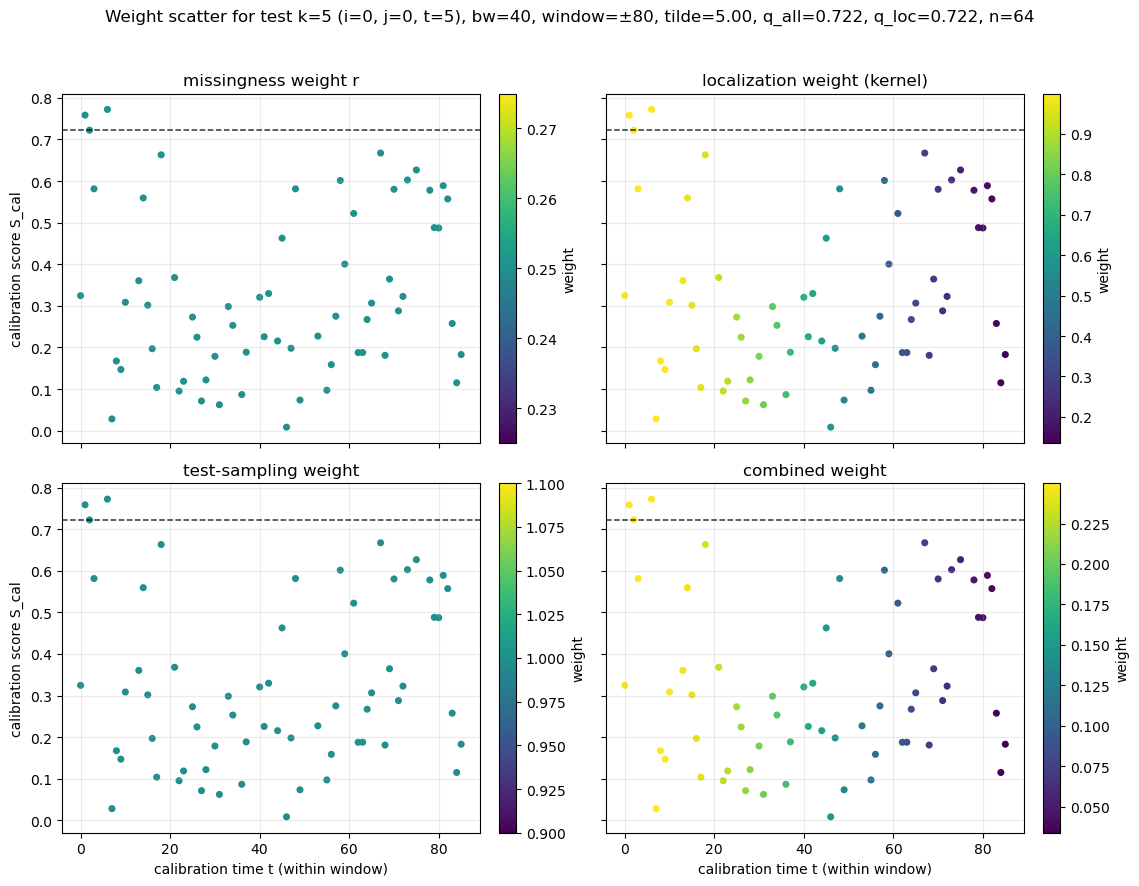

(<Figure size 1150x900 with 8 Axes>,
 [<Axes: title={'center': 'missingness weight r'}, ylabel='calibration score S_cal'>,
  <Axes: title={'center': 'localization weight (kernel)'}>,
  <Axes: title={'center': 'test-sampling weight'}, xlabel='calibration time t (within window)', ylabel='calibration score S_cal'>,
  <Axes: title={'center': 'combined weight'}, xlabel='calibration time t (within window)'>])

In [ ]:
methods_list[3][1].plot_weight_diagnostics(
    X_test_idx=idx_marg,
    test_point=int(idx_marg[0]),
    scatter_time_score=True,
    color_by="all",
    show=True,
)

In [ ]:
cp_results

{'naive': {'marginal': {'coverage': 0.8414524357307193,
   'median_len': 1.9869247403032195,
   'mean_len': 1.9869247403032195,
   'window_abs_gap': 0.2993238674780257},
  'cond_A1': {'coverage': 0.783363802559415,
   'median_len': 1.9869247403032195,
   'mean_len': 1.9869247403032193,
   'window_abs_gap': 0.3212403100775194},
  'cond_A2': {'coverage': 0.9443983402489626,
   'median_len': 1.9869247403032195,
   'mean_len': 1.9869247403032197,
   'window_abs_gap': 0.24444444444444444},
  'cond_mix': {'coverage': 0.8194114421495157,
   'median_len': 1.9869247403032195,
   'mean_len': 1.9869247403032193,
   'window_abs_gap': 0.30649188514357056}},
 'weighted': {'marginal': {'coverage': 0.8985695708712613,
   'median_len': 2.4547053269785493,
   'mean_len': 2.4549082015277146,
   'window_abs_gap': 0.22802569303583506},
  'cond_A1': {'coverage': 0.8560329067641682,
   'median_len': 2.455212741756636,
   'mean_len': 2.4551687951842194,
   'window_abs_gap': 0.24736434108527133},
  'cond_A2': 

In [ ]:
cp_results

{'naive': {'marginal': {'coverage': 0.8520681265206813,
   'median_len': 1.872745215024567,
   'mean_len': 1.8727452150245663,
   'window_abs_gap': 0.20170940170940171},
  'cond_A1': {'coverage': 0.8028209556706966,
   'median_len': 1.872745215024567,
   'mean_len': 1.8727452150245665,
   'window_abs_gap': 0.2384920634920635},
  'cond_A2': {'coverage': 0.9369834710743802,
   'median_len': 1.872745215024567,
   'mean_len': 1.8727452150245663,
   'window_abs_gap': 0.16610644257703092},
  'cond_mix': {'coverage': 0.8329550612800726,
   'median_len': 1.872745215024567,
   'mean_len': 1.872745215024567,
   'window_abs_gap': 0.21540540540540545}},
 'weighted': {'marginal': {'coverage': 0.8952554744525547,
   'median_len': 2.264449493221068,
   'mean_len': 2.265363681927545,
   'window_abs_gap': 0.16462703962703967},
  'cond_A1': {'coverage': 0.8560736902705814,
   'median_len': 2.2670470152284112,
   'mean_len': 2.266612599486826,
   'window_abs_gap': 0.1802248677248677},
  'cond_A2': {'cove

In [ ]:
def plot_cp_results_bars(
    cp_results,
    *,
    metric="coverage",
    blocks=None,
    methods=None,
    alpha=None,
    figsize=(10, 4.8),
    colors=None,
    title=None,
    rotation=0,
):
    """
    Grouped bar plot for cp_results.

    Parameters
    ----------
    cp_results : dict
        Expected structure:
            cp_results[method_name][block_name][metric_name]
    metric : str
        One of {"coverage", "median_len", "window_abs_gap", "mean_len"}.
    blocks : list[str] or None
        Which blocks to plot on x-axis. If None, infer from cp_results.
    methods : list[str] or None
        Which methods to plot. If None, use cp_results keys.
    alpha : float or None
        If metric == "coverage", draws horizontal line at 1-alpha.
    figsize : tuple
    colors : dict or None
        Optional mapping method -> color.
    title : str or None
    rotation : int or float
        Rotation for x tick labels.
    """
    allowed_metrics = {"coverage", "median_len", "window_abs_gap", "mean_len"}
    if metric not in allowed_metrics:
        raise ValueError(f"metric must be one of {allowed_metrics}, got {metric!r}")

    if methods is None:
        methods = list(cp_results.keys())
    else:
        methods = [m for m in methods if m in cp_results]

    if len(methods) == 0:
        raise ValueError("No valid methods found in cp_results.")

    if blocks is None:
        block_set = []
        for m in methods:
            for b in cp_results.get(m, {}).keys():
                if b not in block_set:
                    block_set.append(b)
        blocks = block_set

    if len(blocks) == 0:
        raise ValueError("No blocks to plot.")

    # Default colors
    if colors is None:
        color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get(
            "color", ["C0", "C1", "C2", "C3"]
        )
        colors = {m: color_cycle[k % len(color_cycle)] for k, m in enumerate(methods)}

    x = np.arange(len(blocks), dtype=float)
    n_methods = len(methods)
    width = 0.8 / max(n_methods, 1)

    fig, ax = plt.subplots(figsize=figsize)

    all_vals = []

    for k, method in enumerate(methods):
        vals = []
        for block in blocks:
            val = (
                cp_results.get(method, {})
                .get(block, {})
                .get(metric, np.nan)
            )
            vals.append(float(val) if val is not None else np.nan)

        vals = np.asarray(vals, dtype=float)
        all_vals.append(vals)

        offset = (k - (n_methods - 1) / 2.0) * width
        ax.bar(
            x + offset,
            vals,
            width=width,
            label=method,
            color=colors.get(method, None),
            alpha=0.9,
        )

    # Reference line for coverage
    if metric == "coverage" and alpha is not None:
        ax.axhline(1.0 - alpha, color="black", linestyle="--", linewidth=1.2, alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(blocks, rotation=rotation)
    ax.set_xlabel("block")
    ax.set_ylabel(metric)

    if title is None:
        title = f"{metric} by block and method"
    ax.set_title(title)

    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(loc="best", fontsize=8)

    # Nice y-limits
    all_vals = np.concatenate(all_vals) if all_vals else np.array([], dtype=float)
    finite_vals = all_vals[np.isfinite(all_vals)]
    if finite_vals.size > 0:
        ymin = float(np.min(finite_vals))
        ymax = float(np.max(finite_vals))
        if metric in {"coverage", "window_abs_gap"}:
            ax.set_ylim(bottom=max(0.0, ymin - 0.02), top=max(1.0 if metric == "coverage" else ymax * 1.1, ymax + 0.02))
        else:
            pad = 0.05 * max(1.0, ymax - ymin)
            ax.set_ylim(bottom=max(0.0, ymin - pad), top=ymax + pad)

    fig.tight_layout()
    return fig, ax

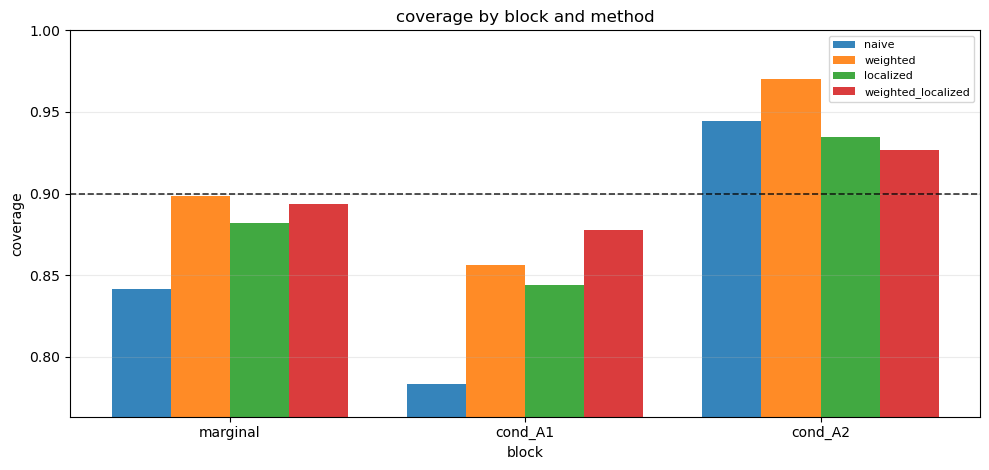

In [ ]:
fig, ax = plot_cp_results_bars(
    cp_results,
    metric="coverage",
    blocks=["marginal", "cond_A1", "cond_A2"],
    methods=["naive", "weighted", "localized", "weighted_localized"],
    alpha=alpha,
)
plt.show()

In [ ]:
def plot_subject_trajectory_with_bands_full(
    cp_methods,
    residual_sub_IJT: np.ndarray,
    obs_sub_IJT: np.ndarray,
    cal_mask: np.ndarray,
    test_mask: np.ndarray,
    X_cal_idx: np.ndarray,
    Y_cal_true: np.ndarray,
    Y_cal_fit: np.ndarray,
    J: int,
    T: int,
    alpha: float,
    *,
    i0: int,
    j0: int,
    band_on: str = "all",          # "all" -> band across all t, "obs" -> only where obs_sub_IJT True
    already_calibrated: bool = True,
    figsize=(12, 10),
):
    """
    One subplot per CP method.
    - Band is computed for EVERY time t in 0..T-1 for the chosen (i0,j0).
    - Cal/test points colored differently.
    - Miscovered test points marked with 'x'.

    Parameters
    ----------
    cp_methods : list of (name, cp_obj)
        cp_obj must implement predict_interval_from_fit.
        If already_calibrated=False, cp_obj must also implement calibrate_from_fit.
    already_calibrated : bool
        If True, skip calibrate_from_fit and use cp_methods as already calibrated.
    """
    residual_sub_IJT = np.asarray(residual_sub_IJT, dtype=float)
    obs_sub_IJT = np.asarray(obs_sub_IJT, dtype=bool)
    cal_mask = np.asarray(cal_mask, dtype=bool)
    test_mask = np.asarray(test_mask, dtype=bool)

    I_sub = residual_sub_IJT.shape[0]
    assert 0 <= i0 < I_sub and 0 <= j0 < J
    assert residual_sub_IJT.shape[1] == J and residual_sub_IJT.shape[2] == T

    t = np.arange(T, dtype=int)

    # True trajectory: break line where originally unobserved
    y_traj = np.where(obs_sub_IJT[i0, j0, :], residual_sub_IJT[i0, j0, :], np.nan)

    # Cal/test times for this (i0,j0)
    t_cal = np.flatnonzero(cal_mask[i0, j0, :])
    t_test = np.flatnonzero(test_mask[i0, j0, :])

    # Full prediction grid indices for this (i0,j0) over ALL times
    X_grid = ((i0 * J + j0) * T + t).astype(np.int64)
    Y_grid_fit = np.zeros(T, dtype=float)  # residual space centered at 0

    # True values at test times (for coverage markers)
    y_test_true = residual_sub_IJT[i0, j0, t_test].astype(float, copy=False)

    n_methods = len(cp_methods)
    fig, axes = plt.subplots(n_methods, 1, sharex=True, sharey=True, figsize=figsize)
    if n_methods == 1:
        axes = [axes]

    for ax, (name, cp_obj) in zip(axes, cp_methods):
        # Calibrate only if needed
        if not already_calibrated:
            if not hasattr(cp_obj, "calibrate_from_fit"):
                raise AttributeError(
                    f"{name} does not implement calibrate_from_fit but already_calibrated=False"
                )
            cp_obj.calibrate_from_fit(X_cal_idx, Y_cal_true, Y_cal_fit)

        # Predict intervals on FULL grid (T points)
        intervals_grid = cp_obj.predict_interval_from_fit(X_grid, Y_grid_fit, alpha)
        lo = intervals_grid[:, 0]
        hi = intervals_grid[:, 1]

        # Decide where to draw the band
        finite_band = np.isfinite(lo) & np.isfinite(hi)
        if band_on == "obs":
            finite_band &= obs_sub_IJT[i0, j0, :]
        elif band_on != "all":
            raise ValueError("band_on must be 'all' or 'obs'.")

        ax.fill_between(t, lo, hi, where=finite_band, alpha=0.25, linewidth=0)

        # True trajectory line
        ax.plot(t, y_traj, linewidth=1.6, alpha=0.9)

        # Cal points
        if t_cal.size > 0:
            ax.scatter(t_cal, residual_sub_IJT[i0, j0, t_cal], s=22, label="cal", zorder=3)

        # Test points + miscoverage markers
        if t_test.size > 0:
            lo_test = lo[t_test]
            hi_test = hi[t_test]
            covered = (y_test_true >= lo_test) & (y_test_true <= hi_test)
            mis = ~covered

            ax.scatter(t_test, y_test_true, s=22, label="test", zorder=4)
            if np.any(mis):
                ax.scatter(
                    t_test[mis],
                    y_test_true[mis],
                    s=70,
                    marker="x",
                    linewidths=2.0,
                    label="miscovered",
                    zorder=6,
                )

            cov_rate = float(np.mean(covered))
            mis_cnt = int(np.sum(mis))
        else:
            cov_rate, mis_cnt = float("nan"), 0

        ax.axhline(0.0, linewidth=0.8, alpha=0.4)
        ax.set_title(
            f"{name} | (i,j)=({i0},{j0}) | test_mis={mis_cnt}/{t_test.size} | test_cov={cov_rate:.3f}"
        )
        ax.grid(True, alpha=0.25)

    axes[-1].set_xlabel("time t")
    for ax in axes:
        ax.set_ylabel("residual")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right", frameon=True)

    fig.tight_layout()
    return fig, axes

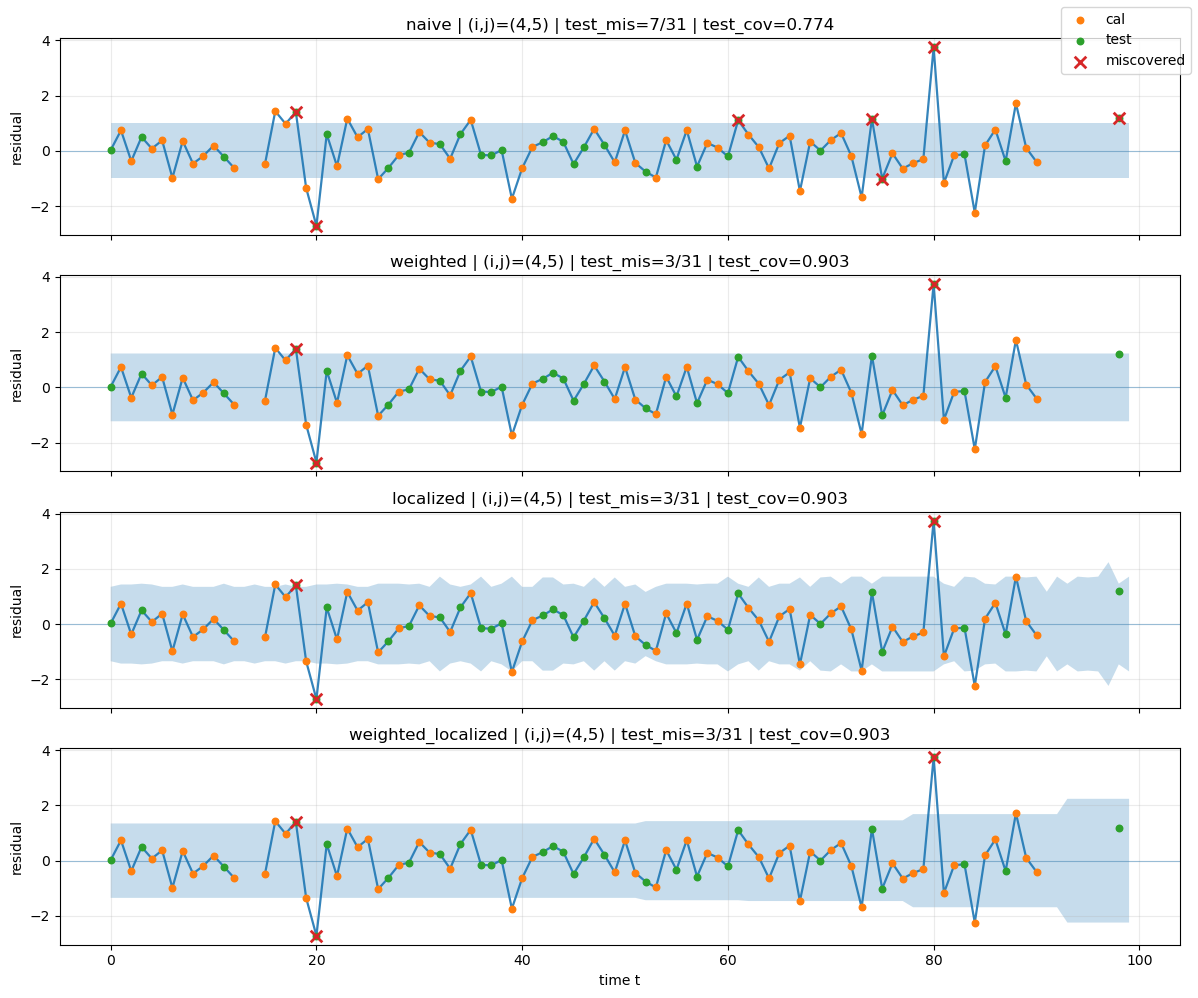

In [ ]:
fig, axes = plot_subject_trajectory_with_bands_full(
    methods_list,
    residual_sub_IJT,
    obs_sub_IJT,
    cal_mask,
    test_mask,
    X_cal_idx,
    Y_cal_true,
    Y_cal_fit,
    J,
    T_sub,
    alpha,
    i0=4,
    j0=J-1,
    already_calibrated=True,
)
plt.show()

In [ ]:
def plot_ranked_subject_variance_intervals(
    Y_full,                         # shape (I, J, T)
    methods_list,                   # list of (name, cp_obj)
    alpha,
    *,
    j=None,
    Y_fit=None,                     # shape (I, J, T); default zeros if None
    time_band_width=0.8,            # width of each subject band on x-axis
    only_missing=False,
    O=None,
    A=None,
    colors=None,
    point_alpha=0.08,
    point_size=6,
    line_width=1.6,
    figsize=(13, 5),
    title = None,
    save_fig = False,
    save_path = None,
):
    """
    Rank subjects by Var(Y[i,j,:]) across time, then:
      - scatter all points Y[i,j,t] within each ranked subject band
      - overlay average CP intervals per subject for each method

    X-axis:
      ranked subjects from low variance to high variance

    Y-axis:
      observed/raw values Y[i,j,t]

    Within each subject band, point x-offset is proportional to time index t/T.

    Parameters
    ----------
    Y_full : np.ndarray, shape (I,J,T)
    methods_list : list of (method_name, cp_obj)
        Each cp_obj must already be calibrated and implement predict_interval_from_fit.
    alpha : float
    j : int or None
        Channel index. Defaults to last channel.
    Y_fit : np.ndarray or None
        Fitted means of shape (I,J,T). If None, zeros are used.
    only_missing : bool
        If True, scatter and interval averaging only use points with miss_pool(O,A)=True.
    O, A : np.ndarray or None
        Required if only_missing=True.
    """
    I, J, T = Y_full.shape
    if j is None:
        j = J - 1

    if Y_fit is None:
        Y_fit = np.zeros_like(Y_full, dtype=float)

    Y_full = np.asarray(Y_full, dtype=float)
    Y_fit = np.asarray(Y_fit, dtype=float)

    if Y_fit.shape != Y_full.shape:
        raise ValueError(f"Y_fit shape {Y_fit.shape} must match Y_full shape {Y_full.shape}")

    if only_missing:
        if O is None or A is None:
            raise ValueError("O and A must be provided when only_missing=True")
        mask_pts = (O * A) != 1
    else:
        mask_pts = np.ones_like(Y_full, dtype=bool)

    # Subject-level variance for channel j
    subj_var = np.array([
        np.nanvar(Y_full[i, j, :][mask_pts[i, j, :]]) if np.any(mask_pts[i, j, :]) else np.nan
        for i in range(I)
    ], dtype=float)
    
    # Rank subjects low -> high variance
    valid_subjects = np.flatnonzero(np.isfinite(subj_var))
    if valid_subjects.size == 0:
        raise ValueError(f"No subjects with finite variance for channel j={j}")
    order = valid_subjects[np.argsort(subj_var[valid_subjects])]
    rank_pos = np.arange(order.size, dtype=float)

    # Default colors
    if colors is None:
        color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get(
            "color", ["C0", "C1", "C2", "C3", "C4"]
        )
        colors = {name: color_cycle[k % len(color_cycle)] for k, (name, _) in enumerate(methods_list)}

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Scatter all points within ranked subject bands
    for r, i in enumerate(order):
        valid_t = np.flatnonzero(mask_pts[i, j, :])
        if valid_t.size == 0:
            continue

        # Map time t into horizontal offsets inside the subject band
        x_offsets = -time_band_width / 2 + time_band_width * (valid_t / max(T - 1, 1))
        x_vals = r + x_offsets
        y_vals = Y_full[i, j, valid_t]

        ax.scatter(
            x_vals,
            y_vals,
            s=point_size,
            color="gray",
            alpha=point_alpha,
            linewidths=0,
            zorder=1,
        )

    # Overlay average intervals for each method
    for method_name, cp_obj in methods_list:
        mean_L = np.full(order.size, np.nan, dtype=float)
        mean_U = np.full(order.size, np.nan, dtype=float)

        for r, i in enumerate(order):
            valid_t = np.flatnonzero(mask_pts[i, j, :])
            if valid_t.size == 0:
                continue

            idx_flat = np.array(
                [((i * J) + j) * T + int(t) for t in valid_t],
                dtype=np.int64,
            )
            y_fit_test = Y_fit.ravel()[idx_flat]
            intervals = cp_obj.predict_interval_from_fit(idx_flat, y_fit_test, alpha=alpha)

            mean_L[r] = float(np.nanmean(intervals[:, 0]))
            mean_U[r] = float(np.nanmean(intervals[:, 1]))

        c = colors[method_name]
        ax.plot(rank_pos, mean_L, color=c, lw=line_width, alpha=0.95)
        ax.plot(rank_pos, mean_U, color=c, lw=line_width, alpha=0.95, label=method_name)
        ax.fill_between(rank_pos, mean_L, mean_U, color=c, alpha=0.05)

    ax.set_xlabel("Subjects ranked by variance (low -> high)")
    ax.set_ylabel(f"Channel {j} values")
    if title is None:
        ax.set_title(f"Ranked subjects by variance with average CP intervals, channel j={j}")
    else:
        ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=8)

    # optional: sparse tick labels
    if order.size > 20:
        step = max(1, I // 10)
        xt = np.arange(0, I, step)
        ax.set_xticks(xt)
        ax.set_xticklabels([str(int(x)) for x in xt])

    plt.tight_layout()
    if save_fig:
        plt.savefig(save_path)
    plt.show()

    return {
        "order": order,                        # original subject ids, filtered
        "subject_variance": subj_var,          # full length-I array
        "valid_subjects": valid_subjects,      # filtered subject ids
    }

In [ ]:
def plot_ranked_subject_coverage_curves(
    Y_full,                         # shape (I, J, T)
    methods_list,                   # list of (name, cp_obj)
    alpha,
    *,
    j=None,
    Y_fit=None,                     # shape (I, J, T); default zeros if None
    only_missing=False,
    O=None,
    A=None,
    colors=None,
    linewidth=1.8,
    markersize=4,
    figsize=(12, 4.5),
    y_mode="coverage",              # "coverage" or "abs_gap"
    save_fig = False,
    save_path = None,
):
    """
    Rank subjects by variance of Y[i,j,:] across time, then for each method:
      - compute empirical coverage over time for each subject i
      - connect these subject-level values into a curve

    y_mode:
      - "coverage": plot empirical coverage
      - "abs_gap": plot |empirical coverage - (1 - alpha)|
    """
    I, J, T = Y_full.shape
    if j is None:
        j = J - 1

    target = 1.0 - alpha

    Y_full = np.asarray(Y_full, dtype=float)
    if Y_fit is None:
        Y_fit = np.zeros_like(Y_full, dtype=float)
    else:
        Y_fit = np.asarray(Y_fit, dtype=float)

    if Y_fit.shape != Y_full.shape:
        raise ValueError(f"Y_fit shape {Y_fit.shape} must match Y_full shape {Y_full.shape}")

    if y_mode not in {"coverage", "abs_gap"}:
        raise ValueError("y_mode must be one of {'coverage', 'abs_gap'}")

    if only_missing:
        if O is None or A is None:
            raise ValueError("O and A must be provided when only_missing=True")
        mask_pts = O & (~A)
    else:
        mask_pts = np.ones_like(Y_full, dtype=bool)

    # Subject-level variance for ranking
    subj_var = np.array([
        np.nanvar(Y_full[i, j, :][mask_pts[i, j, :]]) if np.any(mask_pts[i, j, :]) else np.nan
        for i in range(I)
    ], dtype=float)

    order = np.argsort(np.nan_to_num(subj_var, nan=np.inf))
    x = np.arange(I, dtype=float)

    # Colors
    if colors is None:
        color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get(
            "color", ["C0", "C1", "C2", "C3", "C4"]
        )
        colors = {name: color_cycle[k % len(color_cycle)] for k, (name, _) in enumerate(methods_list)}

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    values_all_methods = []

    for method_name, cp_obj in methods_list:
        subj_val = np.full(I, np.nan, dtype=float)

        for r, i in enumerate(order):
            valid_t = np.flatnonzero(mask_pts[i, j, :])
            if valid_t.size == 0:
                continue

            idx_flat = np.array(
                [((i * J) + j) * T + int(t) for t in valid_t],
                dtype=np.int64,
            )
            y_fit_test = Y_fit.ravel()[idx_flat]
            y_true = Y_full.ravel()[idx_flat]

            intervals = cp_obj.predict_interval_from_fit(idx_flat, y_fit_test, alpha=alpha)
            L = intervals[:, 0]
            U = intervals[:, 1]

            covered = (y_true >= L) & (y_true <= U)
            emp_cov = float(np.mean(covered))

            if y_mode == "coverage":
                subj_val[r] = emp_cov
            else:  # abs_gap
                subj_val[r] = abs(emp_cov - target)

        values_all_methods.append(subj_val)

        ax.plot(
            x,
            subj_val,
            marker="o",
            ms=markersize,
            lw=linewidth,
            color=colors[method_name],
            label=method_name,
        )

    all_vals = np.concatenate([v for v in values_all_methods if v.size > 0])
    finite_vals = all_vals[np.isfinite(all_vals)]

    if y_mode == "coverage":
        ymin = float(np.min(finite_vals)) if finite_vals.size > 0 else 0.0
        ymax = 1.0
        ax.axhline(target, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
        ax.set_ylabel(f"Empirical coverage for channel j={j}")
        ax.set_title(f"Subject-level coverage vs ranked subject variance, channel j={j}")
    else:
        ymin = 0.0
        ymax = float(np.max(finite_vals)) if finite_vals.size > 0 else 1.0
        ymax = max(ymax, 0.01)  # avoid flat axis if everything is near zero
        ax.axhline(0.0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
        ax.set_ylabel(f"|empirical coverage - (1-alpha)| for channel j={j}")
        ax.set_title(f"Subject-level absolute coverage gap vs ranked subject variance, channel j={j}")

    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Subjects ranked by variance (low -> high)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=8)

    if I > 20:
        step = max(1, I // 10)
        xt = np.arange(0, I, step)
        ax.set_xticks(xt)
        ax.set_xticklabels([str(int(v)) for v in xt])

    plt.tight_layout()
    if save_fig:
        plt.savefig(save_path)
    plt.show()

    return {
        "order": order,
        "subject_variance": subj_var,
        "value_by_method": {
            name: val for (name, _), val in zip(methods_list, values_all_methods)
        },
        "y_mode": y_mode,
    }

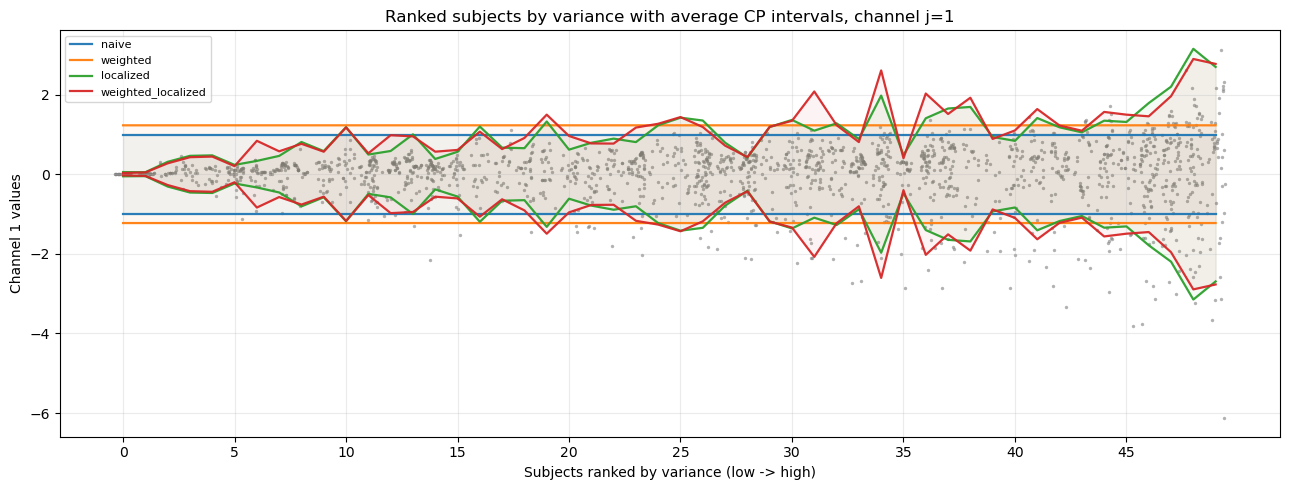

In [ ]:
out = plot_ranked_subject_variance_intervals(
    Y_full=residual_sub_IJT,
    Y_fit=res_sub_fit,
    methods_list=methods_list,
    alpha=alpha,
    j=1,
    only_missing=True,
    O=obs_sub_IJT,
    A=A_eval,
    point_alpha=0.6,
)

In [ ]:
print(out)

{'order': array([45, 43, 12,  8, 29,  9, 16, 11,  0, 39, 23,  6, 21, 30,  7, 10, 24,
       44, 38, 27, 25, 28, 14, 42, 13, 49,  4, 37,  1, 34, 18, 20, 33,  3,
       17, 48, 15, 22, 36, 26,  5], dtype=int64), 'subject_variance': array([0.4530116 , 1.1854215 ,        nan, 1.40140845, 1.01020823,
       3.9358911 , 0.52667004, 0.57847005, 0.        , 0.25893299,
       0.60708796, 0.39485918, 0.        , 0.90857898, 0.73537889,
       1.46057732, 0.26616226, 1.44373688, 1.32623481,        nan,
       1.3549969 , 0.56731761, 1.49382818, 0.48416831, 0.62252478,
       0.69502957, 2.6053863 , 0.68399111, 0.69513399, 0.25517136,
       0.57444679,        nan,        nan, 1.37353373, 1.21270357,
              nan, 1.72123448, 1.03424408, 0.67277705, 0.45773342,
              nan,        nan, 0.80622127, 0.        , 0.64092747,
       0.        ,        nan,        nan, 1.44939149, 0.99941985]), 'valid_subjects': array([ 0,  1,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
     

In [ ]:
channels

['activity_calories',
 'fairly_active_minutes',
 'elevation',
 'steps',
 'minute_deep',
 'minute_wake']

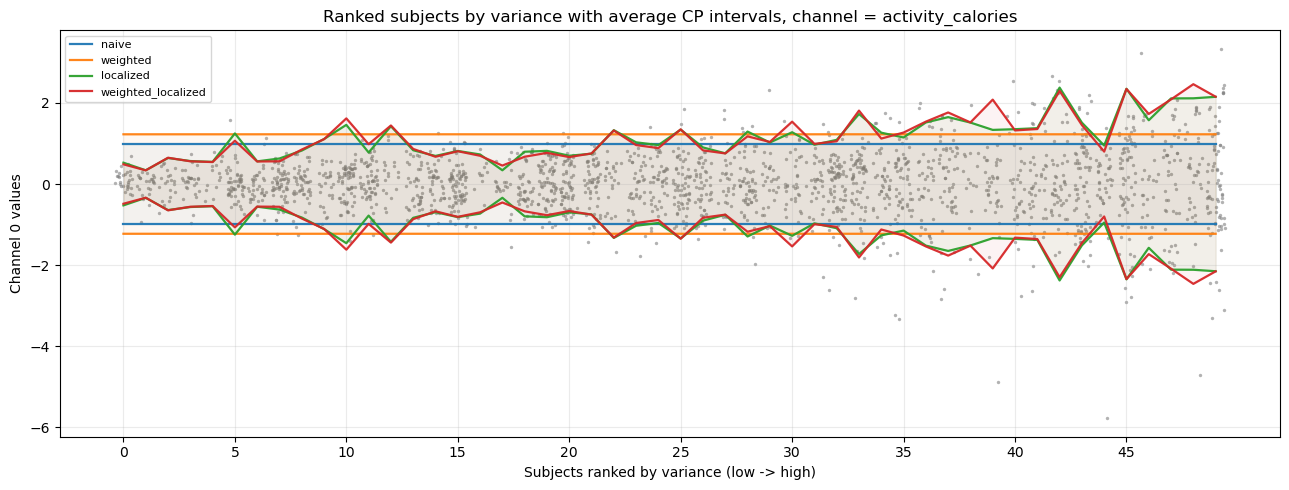

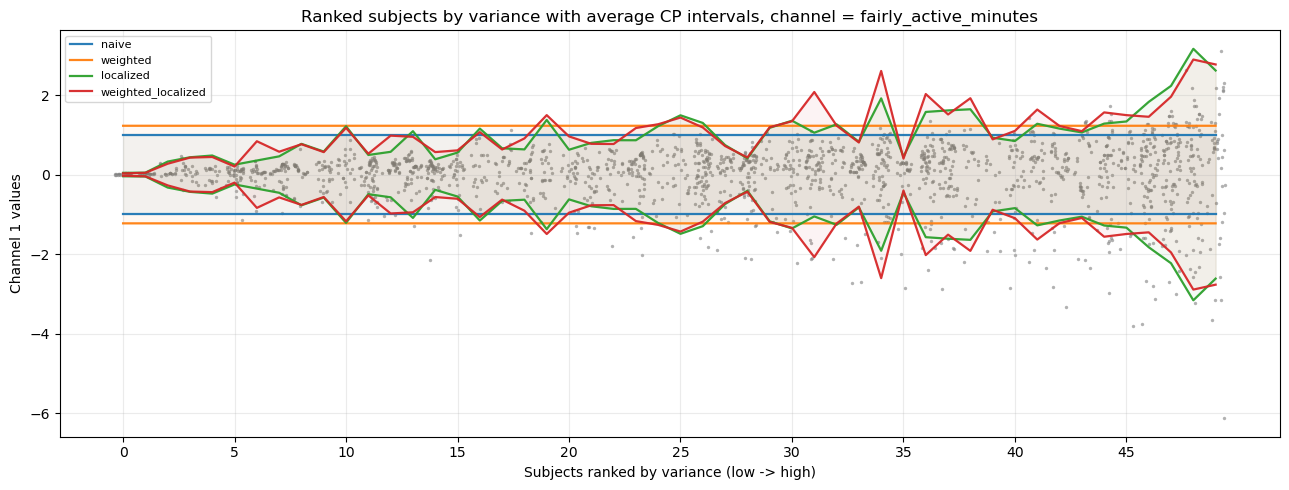

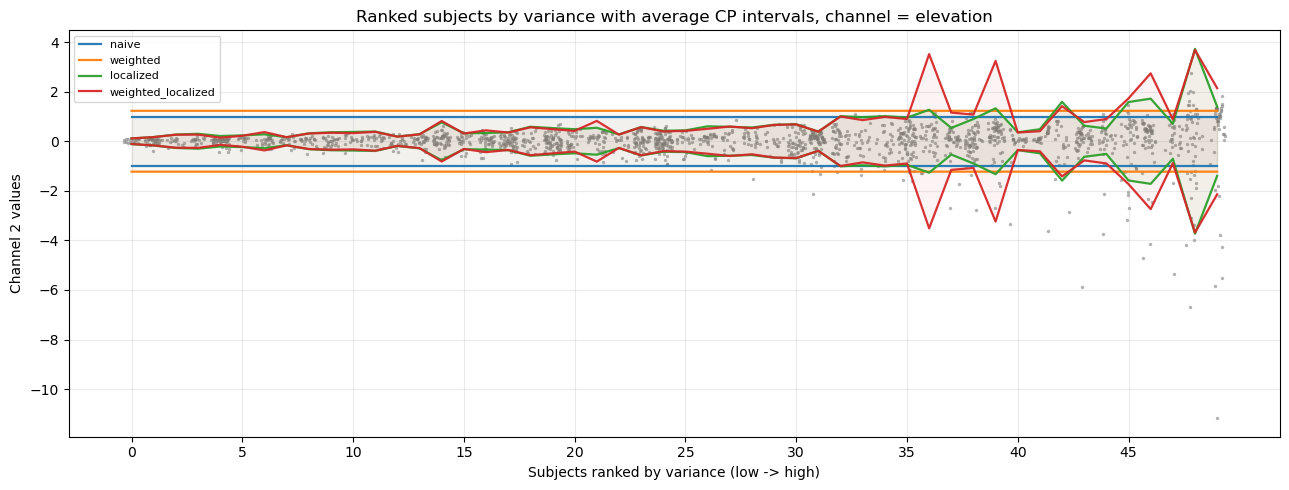

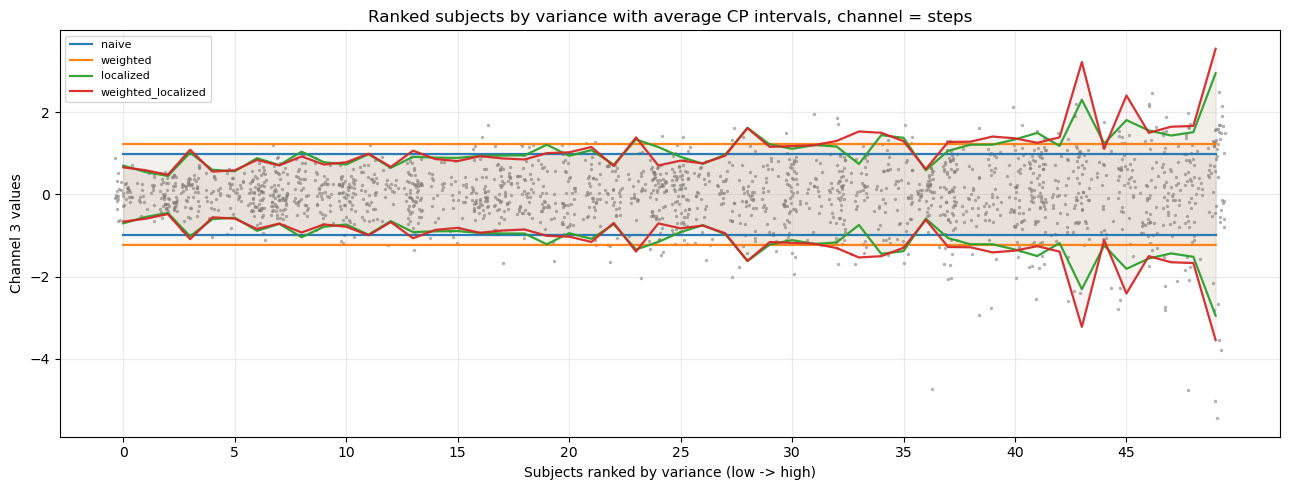

C:\Users\Xiaoke\AppData\Local\Temp\ipykernel_10420\3275546271.py:71: RuntimeWarning: Degrees of freedom <= 0 for slice.
  np.nanvar(Y_full[i, j, :][mask_pts[i, j, :]]) if np.any(mask_pts[i, j, :]) else np.nan
C:\Users\Xiaoke\AppData\Local\Temp\ipykernel_10420\3275546271.py:129: RuntimeWarning: Mean of empty slice
  mean_L[r] = float(np.nanmean(intervals[:, 0]))
C:\Users\Xiaoke\AppData\Local\Temp\ipykernel_10420\3275546271.py:130: RuntimeWarning: Mean of empty slice
  mean_U[r] = float(np.nanmean(intervals[:, 1]))


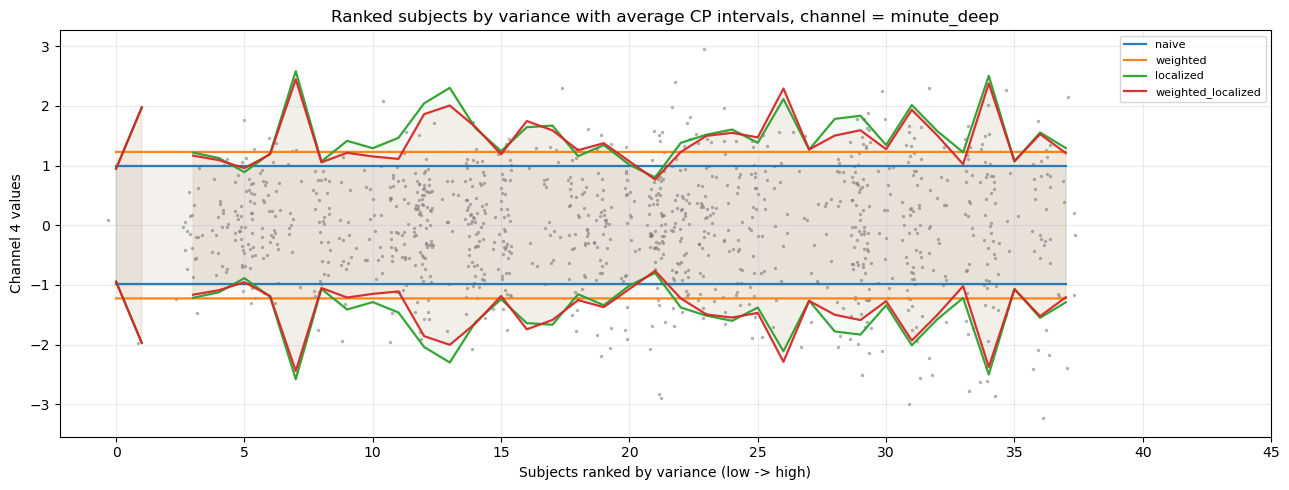

C:\Users\Xiaoke\AppData\Local\Temp\ipykernel_10420\3275546271.py:71: RuntimeWarning: Degrees of freedom <= 0 for slice.
  np.nanvar(Y_full[i, j, :][mask_pts[i, j, :]]) if np.any(mask_pts[i, j, :]) else np.nan
C:\Users\Xiaoke\AppData\Local\Temp\ipykernel_10420\3275546271.py:129: RuntimeWarning: Mean of empty slice
  mean_L[r] = float(np.nanmean(intervals[:, 0]))
C:\Users\Xiaoke\AppData\Local\Temp\ipykernel_10420\3275546271.py:130: RuntimeWarning: Mean of empty slice
  mean_U[r] = float(np.nanmean(intervals[:, 1]))


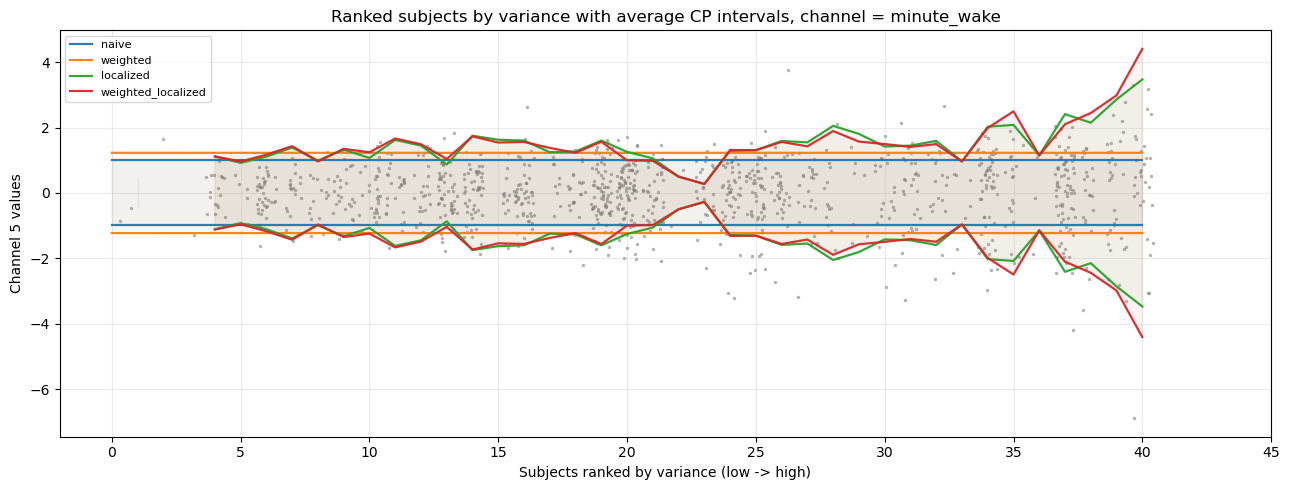

In [ ]:
for j in range(J):
    out = plot_ranked_subject_variance_intervals(
        Y_full=residual_sub_IJT,
        Y_fit=res_sub_fit,
        methods_list=methods_list,
        alpha=alpha,
        j=j,
        only_missing=True,
        O=obs_sub_IJT,
        A=A_eval,
        point_alpha=0.6,
        title = f"Ranked subjects by variance with average CP intervals, channel = {channels[j]}",
        save_fig = True,
        save_path = f"ranked_subject_variance_intervals_j{j}.png",
    )

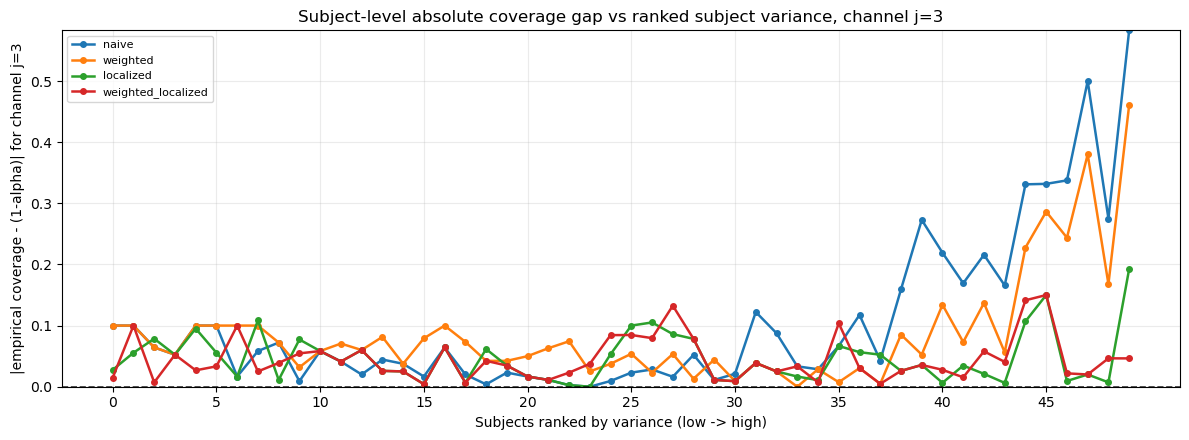

In [ ]:
out_cov = plot_ranked_subject_coverage_curves(
    Y_full=residual_sub_IJT,
    Y_fit=res_sub_fit,
    methods_list=methods_list,
    alpha=alpha,
    j=J-1,
    only_missing=True,
    O=obs_sub_IJT,
    A=A_eval,
    y_mode="abs_gap",
)